<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%209/W09_L1_From_Transformers_to_Vision_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=1lxocPBhn8Y) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%209/NPTEL_Jul24_DL4CV_W09_P01.pdf)

In [1]:
# Week 9, Lecture 1: From Transformers to Vision Transformers
from IPython.display import HTML, display

VIDEO_ID = "1lxocPBhn8Y"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 9, Lecture 1: From Transformers to Vision Transformers

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§9.1 From Transformers to Vision Transformers**.

This notebook takes the transformer encoder of the previous lecture and turns it into an image classifier. We build the Vision Transformer (ViT) piece by piece (patches, linear projection, class token, position embeddings, encoder, head), train a tiny one on MNIST next to a CNN with the same parameter count, look at what its attention heads and position embeddings learned, and then build the Swin Transformer's window attention, shifted windows and patch merging from scratch, verifying every component against an independent reference.

**What you will learn**

- Why a **pixel-as-token** transformer is impossible: $(3 \times 224 \times 224)^2 \approx 2.3 \times 10^{10}$ attention entries per head per layer, and why **16 x 16 patches** bring that down to $(14 \times 14)^2 = 38{,}416$.
- **Patchify** with `unfold`, and the fact that the patch projection *is* a convolution with kernel = stride = patch size (checked with an `assert`).
- The full ViT forward pass $z_0 = [x_{\text{cls}}; x_p^1 E; \ldots; x_p^N E] + E_{\text{pos}}$, followed by pre-norm encoder blocks $z' = z + \text{MSA}(\text{LN}(z))$, $z = z' + \text{MLP}(\text{LN}(z'))$, and its **parameter and FLOP count as functions of patch size**, verified against PyTorch's own counters.
- A measured **data-efficiency curve**: a ViT and a CNN with matched parameters trained on 500, 2000 and 8000 images, which is the lecture's "ViT needs more data, it has less inductive bias" point in miniature.
- **Attention maps, attention rollout and position-embedding similarity** inside the trained ViT.
- How **DeiT** adds a distillation token, and what regularization and augmentation do for ViTs.
- **Swin**: window attention with cost $4hwC^2 + 2M^2hwC$ instead of $4hwC^2 + 2(hw)^2C$, the cyclic shift plus mask trick, relative position bias $A = \text{Softmax}(QK^T/\sqrt{d} + B)V$, and patch merging, all from scratch and all checked.

**Contents**

1. Transformers in NLP: the encoder in one page
2. From an image to a token sequence
3. The Vision Transformer
4. Training a tiny ViT and a matched CNN on MNIST
5. Data efficiency: ViT versus CNN
6. Looking inside the trained ViT
7. Improving ViT: regularization, augmentation and distillation
8. Isotropic versus hierarchical
9. Swin Transformer
10. Task-specific vision transformers
11. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom. The eight training runs in sections 4, 5 and 7 take a few seconds each; every slider only indexes precomputed results.

## Review

Week 8 ended with self-attention and the transformer: every token forms a query, a key and a value, attention weights are $\text{softmax}(QK^T/\sqrt{d})$, several heads run in parallel, and an encoder block is attention plus a position-wise MLP, each wrapped in a residual connection and layer normalization. The order of the tokens enters only through a position embedding added at the input. Nothing in that machinery is specific to words: an encoder consumes any sequence of vectors. This lecture asks the natural question: how do you turn an image into such a sequence, what does the resulting Vision Transformer look like, how does it compare with a CNN, and how does the Swin Transformer put the CNN's multi-scale hierarchy back?

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.flop_counter import FlopCounterMode

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = False

def count_params(module):
    """Number of learnable parameters in a module."""
    return sum(p.numel() for p in module.parameters())

def maxdiff(a, b):
    """Largest absolute difference between two tensors, as a float."""
    return (a - b).abs().max().item()

print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| device:', device)

torch 2.8.0 | torchvision 0.23.0 | device: cpu


## 1. Transformers in NLP: the encoder in one page

The lecture opens with the sentence every vision paper of 2021 opened with:

> "Transformers have revolutionized Natural Language Processing (NLP) tasks by introducing a novel architecture based on self-attention mechanisms."

*Vaswani et al., NeurIPS 2017* introduced the architecture; BERT, RoBERTa, DeBERTa, T5 and the GPT family built machine translation, language understanding, text generation, question answering and named-entity recognition on top of it. Only the **encoder** matters for this lecture, and its whole computation is three formulas.

**Scaled dot-product attention.** For a sequence of $N$ tokens with queries $Q$, keys $K$ and values $V$ (each $N \times d$):

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d}}\right) V .$$

The $N \times N$ matrix inside the softmax is what will cost us dearly on images: **its size is quadratic in the number of tokens**.

**Multi-head self-attention (MSA).** The input $X$ ($N \times D$) is projected to $h$ triples $(Q_i, K_i, V_i)$ of width $d = D/h$, each head attends independently, the $h$ outputs are concatenated and projected back to $D$.

**Encoder block.** With layer normalization applied *before* each sub-layer (the "pre-norm" arrangement ViT uses):

$$z' = z + \text{MSA}(\text{LN}(z)), \qquad z_{\text{out}} = z' + \text{MLP}(\text{LN}(z')).$$

The MLP acts on every token separately with the same weights, so it never mixes positions; only attention does.

### 1.a Attention from scratch, checked against PyTorch

We write the formula with plain tensors and compare it with `F.scaled_dot_product_attention`.

In [3]:
def attention_scratch(q, k, v, mask=None):
    """Scaled dot-product attention.

    q, k, v: (..., N, d).  mask: optional additive term broadcastable to (..., N, N)
    (0 where attention is allowed, a large negative number where it is not).
    Returns the output (..., N, d) and the attention weights (..., N, N).
    """
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    if mask is not None:
        scores = scores + mask
    A = scores.softmax(dim=-1)
    return A @ v, A

set_seed(0)
N, d = 5, 16                                   # 5 "word" tokens, 16-dim per head
q, k, v = torch.randn(N, d), torch.randn(N, d), torch.randn(N, d)
out, A = attention_scratch(q, k, v)
ref = F.scaled_dot_product_attention(q, k, v)
assert torch.allclose(out, ref, atol=1e-6)
print('output shape', tuple(out.shape), '| attention matrix', tuple(A.shape))
print(f'max |scratch - F.scaled_dot_product_attention| = {maxdiff(out, ref):.2e}')
print('each attention row sums to 1:', torch.allclose(A.sum(-1), torch.ones(N)))
print('\nattention weights (row = query token, column = key token):')
print(A)

output shape (5, 16) | attention matrix (5, 5)
max |scratch - F.scaled_dot_product_attention| = 0.00e+00
each attention row sums to 1: True

attention weights (row = query token, column = key token):
tensor([[0.0209, 0.0348, 0.6680, 0.1421, 0.1342],
        [0.0355, 0.2711, 0.4959, 0.0478, 0.1496],
        [0.2575, 0.0939, 0.1613, 0.2512, 0.2360],
        [0.2614, 0.4419, 0.1081, 0.0737, 0.1150],
        [0.0916, 0.0508, 0.1738, 0.1283, 0.5555]])


### 1.b Multi-head attention and the encoder block

`Attention` below is the module every transformer in this notebook uses, ViT and Swin alike. It returns the per-head attention weights too, because we will want to look at them later, and it accepts an additive `mask`, because Swin's shifted windows need one. We verify it against `nn.MultiheadAttention` by copying our weights into PyTorch's module and comparing outputs *and* attention weights.

In [4]:
class Attention(nn.Module):
    """Multi-head self-attention: one fused Linear for Q, K, V, then an output projection."""
    def __init__(self, D, heads):
        super().__init__()
        assert D % heads == 0
        self.h, self.dh = heads, D // heads
        self.qkv = nn.Linear(D, 3 * D)
        self.proj = nn.Linear(D, D)

    def forward(self, x, mask=None):
        B, N, D = x.shape
        qkv = self.qkv(x).view(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)   # (3, B, h, N, dh)
        q, k, v = qkv[0], qkv[1], qkv[2]
        out, attn = attention_scratch(q, k, v, mask)                              # (B, h, N, dh), (B, h, N, N)
        out = out.transpose(1, 2).reshape(B, N, D)                                # concatenate the heads
        return self.proj(out), attn


class Block(nn.Module):
    """Pre-norm transformer encoder block: z + MSA(LN(z)), then z + MLP(LN(z))."""
    def __init__(self, D, heads, mlp_dim):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(D), Attention(D, heads)
        self.ln2 = nn.LayerNorm(D)
        self.mlp = nn.Sequential(nn.Linear(D, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, D))

    def forward(self, x):
        a, attn = self.attn(self.ln1(x))
        x = x + a
        return x + self.mlp(self.ln2(x)), attn


# Check Attention against nn.MultiheadAttention with the same weights.
set_seed(0)
D, heads = 64, 4
attn = Attention(D, heads)
mha = nn.MultiheadAttention(D, heads, batch_first=True)
with torch.no_grad():
    mha.in_proj_weight.copy_(attn.qkv.weight); mha.in_proj_bias.copy_(attn.qkv.bias)
    mha.out_proj.weight.copy_(attn.proj.weight); mha.out_proj.bias.copy_(attn.proj.bias)

x = torch.randn(2, 7, D)                                      # batch of 2 sequences of 7 tokens
out, A = attn(x)
ref, A_ref = mha(x, x, x, need_weights=True, average_attn_weights=False)
assert torch.allclose(out, ref, atol=1e-5) and torch.allclose(A, A_ref, atol=1e-5)
print('Attention output', tuple(out.shape), '| per-head weights', tuple(A.shape))
print(f'max |ours - nn.MultiheadAttention| : output {maxdiff(out, ref):.1e}, weights {maxdiff(A, A_ref):.1e}')

blk = Block(D, heads, mlp_dim=128)
z, _ = blk(x)
print('Block keeps the sequence shape:', tuple(x.shape), '->', tuple(z.shape))
print(f'parameters: Attention {count_params(attn):,} (= 4D^2 + 4D), Block {count_params(blk):,}')

Attention output (2, 7, 64) | per-head weights (2, 4, 7, 7)
max |ours - nn.MultiheadAttention| : output 1.5e-07, weights 6.0e-08
Block keeps the sequence shape: (2, 7, 64) -> (2, 7, 64)
parameters: Attention 16,640 (= 4D^2 + 4D), Block 33,472


## 2. From an image to a token sequence

> "Transformer encoder requires a sequence of vectors as input. In language applications, this sequence is just the set of (ordered) word embeddings that correspond to the tokens within our input. How can we form such a token sequence if our input is an image?"

### 2.a What if every pixel were a token?

The slide does the arithmetic for a $3 \times 224 \times 224$ image: $(3 \times 224 \times 224)^2 \approx 22$ billion. One remark on wording: the slide calls these "parameters", but they are not learned weights. They are the **entries of the attention matrix** $QK^T$, an activation that exists for every head of every layer and that backpropagation has to keep in memory. Either way the number is hopeless, and the cell below recomputes it, together with the number that patches will give us.

In [5]:
def attention_entries(n_tokens):
    """Entries of one N x N attention matrix (one head, one layer) and their float32 size in bytes."""
    return n_tokens ** 2, 4 * n_tokens ** 2

n_pix = 3 * 224 * 224
entries, nbytes = attention_entries(n_pix)
print(f'pixels as tokens : N = 3*224*224 = {n_pix:,}')
print(f'                   N^2 = {entries:.3e} entries  ({entries/1e9:.1f} billion; the slide says 22 billion)')
print(f'                   float32 size = {nbytes/1e9:.1f} GB per head per layer')

N16 = (224 // 16) ** 2
entries16, nbytes16 = attention_entries(N16)
print(f'\n16x16 patches    : N = (224/16)^2 = {N16}')
print(f'                   N^2 = {entries16:,} entries = {nbytes16/1024:.0f} KB in float32  (the slide: 38,416, approx 150 KB)')
print(f'                   reduction factor {entries/entries16:.2e}')

print(f'\n{"patch P":>8} {"grid":>7} {"tokens N":>9} {"N^2 entries":>13} {"float32":>10}')
for P in [8, 14, 16, 28, 32, 56]:
    Np = (224 // P) ** 2
    e, b = attention_entries(Np)
    print(f'{P:>8} {224//P:>4}x{224//P:<2} {Np:>9,} {e:>13,} {b/1024:>7.0f} KB')

pixels as tokens : N = 3*224*224 = 150,528
                   N^2 = 2.266e+10 entries  (22.7 billion; the slide says 22 billion)
                   float32 size = 90.6 GB per head per layer

16x16 patches    : N = (224/16)^2 = 196
                   N^2 = 38,416 entries = 150 KB in float32  (the slide: 38,416, approx 150 KB)
                   reduction factor 5.90e+05

 patch P    grid  tokens N   N^2 entries    float32
       8   28x28       784       614,656    2401 KB
      14   16x16       256        65,536     256 KB
      16   14x14       196        38,416     150 KB
      28    8x8         64         4,096      16 KB
      32    7x7         49         2,401       9 KB
      56    4x4         16           256       1 KB


### 2.b Patchify: the image as $N$ vectors of length $C \cdot P \cdot P$

*Dosovitskiy et al., ICLR 2021* ("An Image is Worth 16x16 Words") cut the $224 \times 224$ image into $196 = 14 \times 14$ patches of $16 \times 16$ pixels. Each patch, of shape $3 \times 16 \times 16$, is flattened to a vector of length $768$ and **linearly projected to a $D$-dimensional vector**. That is the whole tokenizer.

`patchify` does the cutting with `unfold`, in raster order (left to right, top to bottom), and we check it against `F.unfold`. Then comes the observation on the slide titled "Do we have a vision architecture without convolution?!":

> "No! The linear projection from patches is a convolution (with stride being patch size)."

We check that too: a `nn.Linear` on the flattened patches and a `nn.Conv2d` with `kernel_size = stride = P` and the same weights produce the same tokens.

In [6]:
def patchify(x, P):
    """Cut a batch of images (B, C, H, W) into non-overlapping P x P patches.

    Returns (B, N, C*P*P) with N = (H/P)*(W/P), patches in raster order,
    each flattened in (channel, row, column) order.
    """
    B, C, H, W = x.shape
    assert H % P == 0 and W % P == 0, 'image size must be a multiple of the patch size'
    u = x.unfold(2, P, P).unfold(3, P, P)            # (B, C, H/P, W/P, P, P)
    u = u.permute(0, 2, 3, 1, 4, 5)                  # (B, H/P, W/P, C, P, P)
    return u.reshape(B, -1, C * P * P)

set_seed(0)
x = torch.randn(2, 3, 32, 32)
P, D = 8, 48
patches = patchify(x, P)
ref = F.unfold(x, kernel_size=P, stride=P).transpose(1, 2)      # PyTorch's im2col, same ordering
assert torch.equal(patches, ref)
print('image', tuple(x.shape), '-> patches', tuple(patches.shape), f'  (N = {(32//P)**2} patches of {3*P*P} numbers)')
print('patchify == F.unfold:', torch.equal(patches, ref))

# The linear projection IS a strided convolution.
lin = nn.Linear(3 * P * P, D)
conv = nn.Conv2d(3, D, kernel_size=P, stride=P)
with torch.no_grad():
    conv.weight.copy_(lin.weight.view(D, 3, P, P))               # same numbers, reshaped
    conv.bias.copy_(lin.bias)
tok_lin = lin(patches)                                           # (B, N, D)
tok_conv = conv(x).flatten(2).transpose(1, 2)                    # (B, D, H/P, W/P) -> (B, N, D)
assert torch.allclose(tok_lin, tok_conv, atol=1e-5)
print(f'\nLinear on patches {tuple(tok_lin.shape)} vs Conv2d(kernel={P}, stride={P}) {tuple(tok_conv.shape)}: '
      f'max |diff| = {maxdiff(tok_lin, tok_conv):.1e}')
print(f'parameters of the projection: {count_params(lin):,} (Linear) = {count_params(conv):,} (Conv2d)')

image (2, 3, 32, 32) -> patches (2, 16, 192)   (N = 16 patches of 192 numbers)
patchify == F.unfold: True

Linear on patches (2, 16, 48) vs Conv2d(kernel=8, stride=8) (2, 16, 48): max |diff| = 0.0e+00
parameters of the projection: 9,264 (Linear) = 9,264 (Conv2d)


The picture below shows one MNIST digit cut at four patch sizes. With $P = 2$ there are 196 tokens and each token is a $2 \times 2$ blur of nothing recognizable; with $P = 14$ there are four tokens, each a quadrant of the digit. The tokenizer decides how much of the "what is where" question is left to attention.

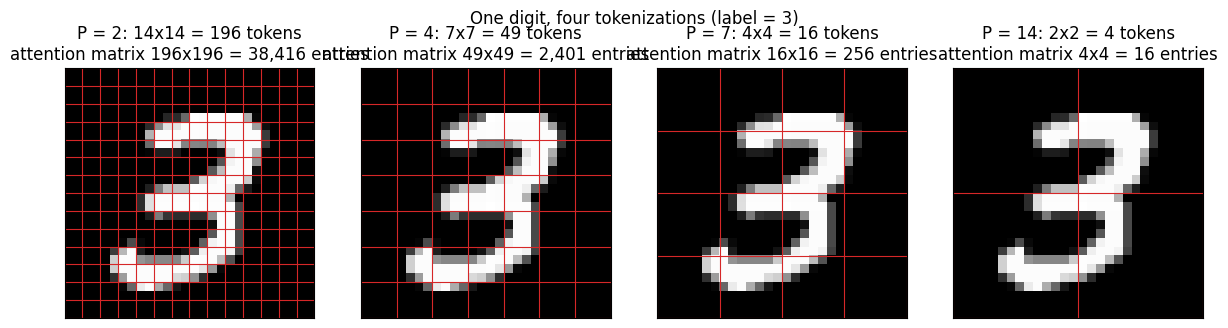

In [7]:
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
digit = mnist_train.data[7].float().div(255)      # one 28 x 28 digit, values in [0, 1]

def draw_patch_grid(ax, img, P, color='tab:red'):
    """Draw an image with a P x P patch grid over it."""
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    H, W = img.shape
    for i in range(0, H + 1, P):
        ax.axhline(i - 0.5, color=color, lw=0.8)
        ax.axvline(i - 0.5, color=color, lw=0.8)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(12, 3.3))
for ax, P in zip(axes, [2, 4, 7, 14]):
    Np = (28 // P) ** 2
    draw_patch_grid(ax, digit.numpy(), P)
    ax.set_title(f'P = {P}: {28//P}x{28//P} = {Np} tokens\nattention matrix {Np}x{Np} = {Np*Np:,} entries')
plt.suptitle('One digit, four tokenizations (label = %d)' % mnist_train.targets[7].item())
plt.tight_layout(); plt.show()

### Widget 1: patch size versus tokens and attention cost

Pick a patch size in the dropdown. The grid redraws, and the bars show the number of tokens $N$ and the number of attention entries $N^2$ (log scale). Going from $P = 2$ to $P = 4$ divides the tokens by 4 and the attention entries by 16; the linear projection, on the other hand, grows with $P^2$. Every design choice in a ViT is a trade between these two curves.

In [8]:
def patch_size_explorer(P=4, D=64):
    Np = (28 // P) ** 2
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    draw_patch_grid(axes[0], digit.numpy(), P)
    axes[0].set_title(f'P = {P}: {28//P}x{28//P} = {Np} tokens')
    names = ['tokens N', 'attention entries N^2', f'projection params (P*P*{D}+{D})']
    vals = [Np, Np * Np, P * P * D + D]
    bars = axes[1].bar(names, vals, color=['#4C72B0', '#C44E52', '#55A868'])
    axes[1].set_yscale('log'); axes[1].set_ylabel('count (log)')
    for b, v in zip(bars, vals):
        axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    axes[1].margins(y=0.3); axes[1].tick_params(axis='x', labelsize=8)
    axes[1].set_title('what grows, what shrinks')
    plt.tight_layout(); plt.show()

interact(patch_size_explorer,
         P=Dropdown(options=[2, 4, 7, 14], value=4, description='patch P'),
         D=IntSlider(min=16, max=256, step=16, value=64, description='embed D'));

interactive(children=(Dropdown(description='patch P', index=1, options=(2, 4, 7, 14), value=4), IntSlider(valu…

## 3. The Vision Transformer

The slides build the architecture in four steps, each adding one line to the picture:

1. **$N$ input patches, each of shape $3 \times 16 \times 16$.**
2. **Linear projection to a $D$-dimensional vector**, the same $E$ for every patch.
3. **Add positional embedding: a learned $D$-dimensional vector** per position (ViT learns them; there is no sinusoid). Without it the encoder is permutation invariant and could not tell a stroke at the top of the image from the same stroke at the bottom.
4. **Output vectors. Exact same as NLP Transformer!**

Two details from the paper complete it. A learnable **class token** $x_{\text{cls}}$ is prepended to the sequence, so the encoder runs on $N + 1$ tokens, and only that token's output goes to the classifier head, exactly like BERT's `[CLS]`. And the encoder is pre-norm, with a final layer norm before the head:

$$z_0 = [x_{\text{cls}};\ x_p^1 E;\ \ldots;\ x_p^N E] + E_{\text{pos}}, \qquad z_\ell = \text{Block}(z_{\ell - 1}), \qquad y = \text{Linear}(\text{LN}(z_L^0)).$$

`TinyViT` is that, with the projection written as the strided convolution the slide talks about. It also has a `trace` flag that prints every intermediate shape, and it returns the attention weights of every layer when asked.

In [9]:
class TinyViT(nn.Module):
    """Vision Transformer for small images: patch conv, class token, learned positions, pre-norm encoder, head."""
    def __init__(self, img=28, P=4, C=1, D=64, depth=3, heads=4, mlp_dim=128, n_cls=10):
        super().__init__()
        self.P, N = P, (img // P) ** 2
        self.embed = nn.Conv2d(C, D, kernel_size=P, stride=P)          # the linear projection, as a conv
        self.cls = nn.Parameter(torch.zeros(1, 1, D))                   # learnable class token
        self.pos = nn.Parameter(torch.randn(1, N + 1, D) * 0.02)         # learned position embedding (incl. cls)
        self.blocks = nn.ModuleList([Block(D, heads, mlp_dim) for _ in range(depth)])
        self.ln = nn.LayerNorm(D)
        self.head = nn.Linear(D, n_cls)

    def forward(self, x, return_attn=False, trace=False):
        B = x.shape[0]
        t = self.embed(x)                                               # (B, D, H/P, W/P)
        if trace: print(f'{"patch conv":14s} {tuple(t.shape)}')
        t = t.flatten(2).transpose(1, 2)                                # (B, N, D)  raster order
        if trace: print(f'{"tokens":14s} {tuple(t.shape)}')
        t = torch.cat([self.cls.expand(B, -1, -1), t], dim=1) + self.pos   # (B, N+1, D)
        if trace: print(f'{"+cls +pos":14s} {tuple(t.shape)}')
        attn_maps = []
        for i, blk in enumerate(self.blocks):
            t, a = blk(t)
            attn_maps.append(a)
            if trace: print(f'{"block %d" % (i+1):14s} {tuple(t.shape)}   attention {tuple(a.shape)}')
        out = self.head(self.ln(t[:, 0]))                               # class token only
        if trace: print(f'{"logits":14s} {tuple(out.shape)}')
        return (out, attn_maps) if return_attn else out

set_seed(0)
vit = TinyViT(img=28, P=4, C=1, D=64, depth=3, heads=4, mlp_dim=128)
x = torch.randn(2, 1, 28, 28)
_ = vit(x, trace=True)
print(f'\nTinyViT parameters: {count_params(vit):,}')

patch conv     (2, 64, 7, 7)
tokens         (2, 49, 64)
+cls +pos      (2, 50, 64)
block 1        (2, 50, 64)   attention (2, 4, 50, 50)
block 2        (2, 50, 64)   attention (2, 4, 50, 50)
block 3        (2, 50, 64)   attention (2, 4, 50, 50)
logits         (2, 10)

TinyViT parameters: 105,546


### 3.a The MLP is a stack of $1 \times 1$ convolutions

The slide's last remark on "vision without convolution" is that "MLPs in Transformer are stacks of $1 \times 1$ convolution". The MLP applies the same two linear maps to every token; if the tokens are laid back on their $7 \times 7$ grid, a linear map per position is by definition a $1 \times 1$ convolution. We copy the weights across and check.

In [10]:
mlp = vit.blocks[0].mlp                                    # Linear(64,128) -> GELU -> Linear(128,64)
fc1, fc2 = mlp[0], mlp[2]
conv1 = nn.Conv2d(64, 128, kernel_size=1)
conv2 = nn.Conv2d(128, 64, kernel_size=1)
with torch.no_grad():
    conv1.weight.copy_(fc1.weight[:, :, None, None]); conv1.bias.copy_(fc1.bias)
    conv2.weight.copy_(fc2.weight[:, :, None, None]); conv2.bias.copy_(fc2.bias)

set_seed(1)
tokens = torch.randn(2, 49, 64)                            # 49 patch tokens of a 28x28 image with P = 4
grid = tokens.transpose(1, 2).reshape(2, 64, 7, 7)         # tokens laid back on the 7x7 grid
out_mlp = mlp(tokens)
out_conv = conv2(F.gelu(conv1(grid))).flatten(2).transpose(1, 2)
assert torch.allclose(out_mlp, out_conv, atol=1e-5)
print(f'MLP on tokens {tuple(out_mlp.shape)} == two 1x1 convs on the {tuple(grid.shape[1:])} grid: '
      f'max |diff| = {maxdiff(out_mlp, out_conv):.1e}')

MLP on tokens (2, 49, 64) == two 1x1 convs on the (64, 7, 7) grid: max |diff| = 0.0e+00


### 3.b Parameters and FLOPs as functions of the patch size

With $N = (H/P)^2$ patches, $T = N + 1$ tokens, width $D$, $L$ layers and an MLP of width $D_m$:

| Part | Parameters | Multiply-accumulates (one image) |
|---|---|---|
| patch projection | $D \cdot CP^2 + D$ | $N \cdot D \cdot CP^2$ |
| class token + positions | $D + (N+1)D$ | 0 |
| attention, per layer | $4D^2 + 4D$ | $4TD^2$ (Q, K, V, output) $+\ 2T^2D$ ($QK^T$ and $AV$) |
| MLP, per layer | $2DD_m + D_m + D$ | $2TDD_m$ |
| layer norms | $4D$ per layer $+ 2D$ | 0 (no multiplies worth counting) |
| head | $Dn_{\text{cls}} + n_{\text{cls}}$ | $Dn_{\text{cls}}$ |

Only two terms depend on the patch size: the projection ($\propto P^2$) and the positions ($\propto N$), so **the parameter count is almost independent of $P$**, which is what the slide's "(14 x 14)$^2$ = 38,416 per layer" line is really about: the cost that explodes with resolution is the $2T^2D$ attention term, an activation, not a weight. We check both formulas against PyTorch: parameters against `sum(p.numel())`, FLOPs against `torch.utils.flop_counter` (which reports $2 \times$ multiply-accumulates).

In [11]:
def vit_params(img=28, C=1, P=4, D=64, depth=3, mlp_dim=128, n_cls=10):
    """Parameter count of TinyViT from the table above."""
    N = (img // P) ** 2
    per_layer = 4 * D + (3 * D * D + 3 * D) + (D * D + D) + (D * mlp_dim + mlp_dim + mlp_dim * D + D)
    return (D * C * P * P + D) + (N + 1) * D + D + depth * per_layer + 2 * D + (D * n_cls + n_cls)

def vit_macs(img=28, C=1, P=4, D=64, depth=3, mlp_dim=128, n_cls=10):
    """Multiply-accumulates of one TinyViT forward pass on one image."""
    N = (img // P) ** 2
    T = N + 1
    per_layer = 4 * T * D * D + 2 * T * T * D + 2 * T * D * mlp_dim
    return N * D * C * P * P + depth * per_layer + D * n_cls

print(f'{"P":>3} {"tokens":>7} {"params":>9} {"MACs formula":>13} {"FLOPs counted":>14} {"2*MACs":>12}')
for P in [2, 4, 7, 14]:
    m = TinyViT(P=P)
    with FlopCounterMode(display=False) as fc:
        m(torch.randn(1, 1, 28, 28))
    counted = fc.get_total_flops()
    assert count_params(m) == vit_params(P=P)
    assert counted == 2 * vit_macs(P=P)
    print(f'{P:>3} {(28//P)**2:>7} {count_params(m):>9,} {vit_macs(P=P):>13,} {counted:>14,} {2*vit_macs(P=P):>12,}')
print('parameter formula == count_params and 2*MACs == FlopCounterMode for every P')

# The same formulas on the real thing: ViT-Base/16 on 224x224 RGB, 1000 classes.
pb = vit_params(img=224, C=3, P=16, D=768, depth=12, mlp_dim=3072, n_cls=1000)
mb = vit_macs(img=224, C=3, P=16, D=768, depth=12, mlp_dim=3072, n_cls=1000)
print(f'\nViT-B/16: {pb/1e6:.1f} M parameters, {mb/1e9:.1f} GMACs per image')
print('(Touvron et al. report 86 M parameters and 17.6 G for ViT-B, counting multiply-accumulates as FLOPs)')

  P  tokens    params  MACs formula  FLOPs counted       2*MACs
  2     196   114,186    34,319,360     68,638,720   68,638,720
  4      49   105,546     5,926,016     11,852,032   11,852,032
  7      16   105,546     1,832,960      3,665,920    3,665,920
 14       4   114,186       551,936      1,103,872    1,103,872
parameter formula == count_params and 2*MACs == FlopCounterMode for every P

ViT-B/16: 86.6 M parameters, 17.6 GMACs per image
(Touvron et al. report 86 M parameters and 17.6 G for ViT-B, counting multiply-accumulates as FLOPs)


The sweep below is the ViT-Base configuration at every patch size that divides 224. Parameters barely move; the attention term makes the cost of small patches explode, and the projection makes very large patches slightly more expensive again in parameters. The paper picks $P = 16$ as its accuracy-versus-compute sweet spot (hence its title) and also trains /32 and /14 variants.

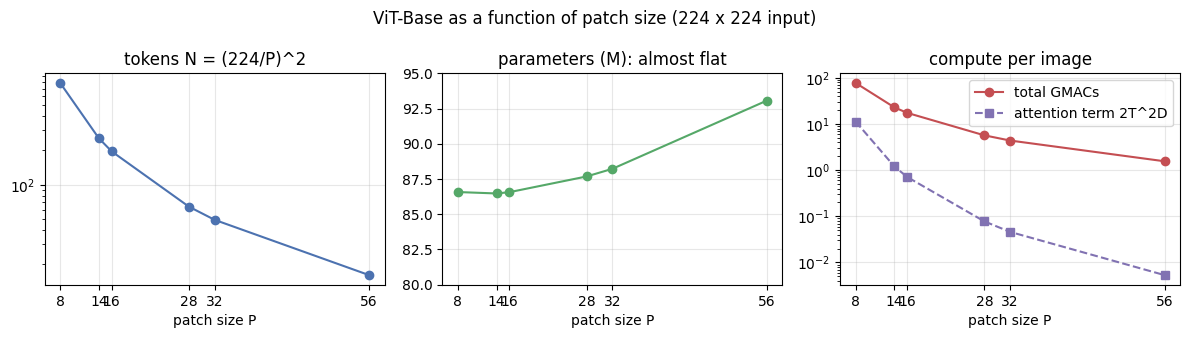

P =  8:  784 tokens,  86.6 M params,    78.1 GMACs
P = 14:  256 tokens,  86.5 M params,    23.2 GMACs
P = 16:  196 tokens,  86.6 M params,    17.6 GMACs
P = 28:   64 tokens,  87.7 M params,     5.7 GMACs
P = 32:   49 tokens,  88.2 M params,     4.4 GMACs
P = 56:   16 tokens,  93.1 M params,     1.6 GMACs


In [12]:
Ps = [8, 14, 16, 28, 32, 56]
toks = [(224 // P) ** 2 for P in Ps]
params_B = [vit_params(img=224, C=3, P=P, D=768, depth=12, mlp_dim=3072, n_cls=1000) / 1e6 for P in Ps]
macs_B = [vit_macs(img=224, C=3, P=P, D=768, depth=12, mlp_dim=3072, n_cls=1000) / 1e9 for P in Ps]
attn_B = [12 * 2 * (n + 1) ** 2 * 768 / 1e9 for n in toks]        # the 2 T^2 D term alone, all 12 layers

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].plot(Ps, toks, 'o-', color='#4C72B0'); axes[0].set_yscale('log')
axes[0].set_title('tokens N = (224/P)^2'); axes[0].set_xlabel('patch size P')
axes[1].plot(Ps, params_B, 'o-', color='#55A868'); axes[1].set_ylim(80, 95)
axes[1].set_title('parameters (M): almost flat'); axes[1].set_xlabel('patch size P')
axes[2].plot(Ps, macs_B, 'o-', color='#C44E52', label='total GMACs')
axes[2].plot(Ps, attn_B, 's--', color='#8172B2', label='attention term 2T^2D')
axes[2].set_yscale('log'); axes[2].legend(); axes[2].set_title('compute per image'); axes[2].set_xlabel('patch size P')
for ax in axes:
    ax.set_xticks(Ps); ax.grid(alpha=0.3)
plt.suptitle('ViT-Base as a function of patch size (224 x 224 input)')
plt.tight_layout(); plt.show()
for P, n, p, m in zip(Ps, toks, params_B, macs_B):
    print(f'P = {P:2d}: {n:4d} tokens, {p:5.1f} M params, {m:7.1f} GMACs')

## 4. Training a tiny ViT and a matched CNN on MNIST

To compare the two families fairly we need two models with the **same number of parameters**, trained with the **same recipe on the same images**. The ViT is the one above: patch size 4 (49 tokens), $D = 64$, 3 blocks, 4 heads, MLP width 128, 105,546 parameters. The CNN is a LeNet-style network with two $3 \times 3$ convolutions, two max-pools and a hidden linear layer, sized to 105,866 parameters (0.3% more).

The data is an **8,000-image subset of MNIST** (loaded into one tensor, normalized with the usual mean 0.1307 and standard deviation 0.3081) and 2,000 test images. The recipe, identical for every run in this notebook: AdamW, learning rate $2 \times 10^{-3}$ with 50 warmup steps and cosine decay, batch 128, 500 steps (8 passes over the 8,000 images). Transformers are sensitive to the warmup; the CNN would train fine without it.

train (8000, 1, 28, 28) | test (2000, 1, 28, 28)
class counts in the 8000 training images: [795, 906, 788, 811, 799, 702, 798, 853, 753, 795]


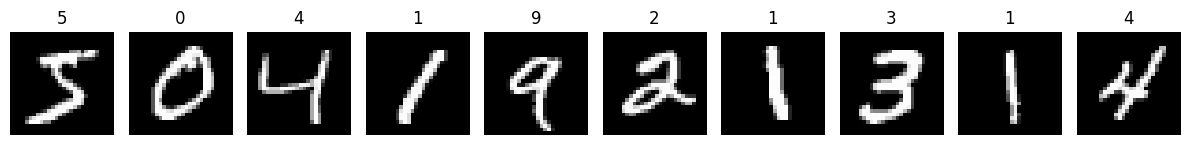

In [13]:
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True)

def prep(ds, n):
    """First n images as a normalized float tensor (n, 1, 28, 28) plus labels."""
    x = ds.data[:n].float().div(255).sub(0.1307).div(0.3081).unsqueeze(1)
    return x, ds.targets[:n].clone()

Xtr, Ytr = prep(mnist_train, 8000)
Xte, Yte = prep(mnist_test, 2000)
print('train', tuple(Xtr.shape), '| test', tuple(Xte.shape))
print('class counts in the 8000 training images:', torch.bincount(Ytr).tolist())

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for ax, i in zip(axes, range(10)):
    ax.imshow(Xtr[i, 0], cmap='gray'); ax.set_title(str(Ytr[i].item())); ax.axis('off')
plt.tight_layout(); plt.show()

In [14]:
class TinyCNN(nn.Module):
    """LeNet-style CNN: conv-pool, conv-pool, hidden linear, classifier. Sized to match TinyViT."""
    def __init__(self, c1=16, c2=32, hidden=64, n_cls=10):
        super().__init__()
        self.stage1 = nn.Sequential(nn.Conv2d(1, c1, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))    # 28 -> 14
        self.stage2 = nn.Sequential(nn.Conv2d(c1, c2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))   # 14 -> 7
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(c2 * 7 * 7, hidden), nn.ReLU(), nn.Linear(hidden, n_cls))

    def forward(self, x):
        return self.classifier(self.stage2(self.stage1(x)))

n_vit, n_cnn = count_params(TinyViT()), count_params(TinyCNN())
print(f'TinyViT parameters: {n_vit:,}')
print(f'TinyCNN parameters: {n_cnn:,}   (ratio {n_cnn/n_vit:.3f})')

TinyViT parameters: 105,546
TinyCNN parameters: 105,866   (ratio 1.003)


In [15]:
def lr_schedule(step, steps, warmup=50):
    """Linear warmup to 1, then cosine decay to 0. Returned as a multiplier of the base lr."""
    if step < warmup:
        return (step + 1) / warmup
    return 0.5 * (1 + math.cos(math.pi * (step - warmup) / (steps - warmup)))

@torch.no_grad()
def accuracy(model, X, Y, bs=500):
    """Classification accuracy of a model on tensors X, Y (moved to device in batches)."""
    model.eval()
    correct = 0
    for i in range(0, len(X), bs):
        logits = model(X[i:i + bs].to(device))
        correct += (logits.argmax(1).cpu() == Y[i:i + bs]).sum().item()
    model.train()
    return correct / len(X)

def train_model(model, X, Y, steps=500, batch=128, lr=2e-3, seed=0, log_every=100, teacher=None, tau=1.0, lam=0.5, hard=False):
    """Train `model` on (X, Y) with AdamW + warmup/cosine. Returns the per-step loss list and the elapsed seconds.

    If `teacher` is given, `model` must return (class logits, distillation logits) in train mode and the
    loss is (1 - lam) * CE(class logits, y) + lam * tau^2 * KL(softmax(teacher/tau) || softmax(dist/tau)),
    the DeiT soft-distillation loss of section 7. With hard=True the KL term is replaced by
    CE(distillation logits, argmax of the teacher), DeiT's hard distillation.
    """
    set_seed(seed)
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: lr_schedule(s, steps))
    g = torch.Generator().manual_seed(seed)
    losses, t0 = [], time.time()
    for step in range(steps):
        idx = torch.randint(0, len(X), (batch,), generator=g)
        xb, yb = X[idx].to(device), Y[idx].to(device)
        if teacher is None:
            loss = F.cross_entropy(model(xb), yb)
        else:
            logits_cls, logits_dist = model(xb)
            with torch.no_grad():
                t_logits = teacher(xb)
            if hard:
                dist_loss = F.cross_entropy(logits_dist, t_logits.argmax(1))     # the teacher's label as a hard target
            else:
                dist_loss = F.kl_div(F.log_softmax(logits_dist / tau, -1), F.softmax(t_logits / tau, -1),
                                     reduction='batchmean') * tau * tau
            loss = (1 - lam) * F.cross_entropy(logits_cls, yb) + lam * dist_loss
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
        if (step + 1) % log_every == 0:
            print(f'  step {step+1:4d}  loss {np.mean(losses[-log_every:]):.4f}  lr {sched.get_last_lr()[0]:.2e}  {time.time()-t0:5.1f} s')
    return losses, time.time() - t0

results = {}                       # (model name, training-set size) -> dict(acc, losses, seconds)
models = {}

for name, make in [('ViT', TinyViT), ('CNN', TinyCNN)]:
    print(f'{name} on 8000 images')
    set_seed(0); model = make()
    losses, secs = train_model(model, Xtr, Ytr)
    acc = accuracy(model, Xte, Yte)
    results[(name, 8000)] = dict(acc=acc, losses=losses, seconds=secs, train_acc=accuracy(model, Xtr[:2000], Ytr[:2000]))
    models[(name, 8000)] = model
    print(f'  -> test accuracy {acc:.4f} | accuracy on 2000 training images {results[(name, 8000)]["train_acc"]:.4f} | {secs:.1f} s\n')

ViT on 8000 images


  step  100  loss 1.8027  lr 1.94e-03    2.8 s


  step  200  loss 0.7665  lr 1.50e-03    5.6 s


  step  300  loss 0.3777  lr 8.26e-04    8.3 s


  step  400  loss 0.2067  lr 2.34e-04   11.1 s


...

  step  100  loss 0.7806  lr 1.94e-03    1.3 s


  step  200  loss 0.1051  lr 1.50e-03    2.7 s


  step  300  loss 0.0550  lr 8.26e-04    4.0 s


  step  400  loss 0.0359  lr 2.34e-04    5.4 s


  step  500  loss 0.0287  lr 0.00e+00    6.7 s
  -> test accuracy 0.9720 | accuracy on 2000 training images 0.9915 | 6.7 s



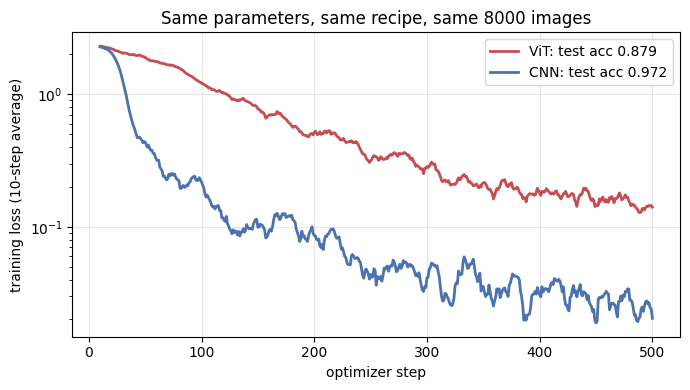

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, col in [('ViT', '#C44E52'), ('CNN', '#4C72B0')]:
    l = np.array(results[(name, 8000)]['losses'])
    smooth = np.convolve(l, np.ones(10) / 10, mode='valid')
    ax.plot(np.arange(len(smooth)) + 10, smooth, color=col, lw=2,
            label=f'{name}: test acc {results[(name, 8000)]["acc"]:.3f}')
ax.set_xlabel('optimizer step'); ax.set_ylabel('training loss (10-step average)'); ax.set_yscale('log')
ax.set_title('Same parameters, same recipe, same 8000 images'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The CNN wins clearly on this budget, and it wins on training loss as well as on test accuracy: it is not only generalizing better, it is also *optimizing* faster. A convolution already knows that nearby pixels belong together and that a stroke means the same thing wherever it appears; the ViT has to discover both from data, through the position embeddings and the attention weights. The next section measures how that gap depends on the amount of data.

## 5. Data efficiency: ViT versus CNN

The slides titled "Vision Transformer (ViT) vs ResNets" show the central figure of the ViT paper: pre-trained on ImageNet-1k (1.3 M images), ViT is **worse** than a ResNet of similar size; pre-trained on ImageNet-21k (14 M) they are roughly even; pre-trained on JFT-300M (300 M images) the ViT is **better**, and the largest ViT (ViT-H/14) is best of all. The paper's reading: a ViT has **less inductive bias** than a CNN (no locality, no translation equivariance built in, only the MLP is local and only the patch cut is translation-aware), so it needs more data to learn what the CNN was given for free, and once it has that data, the lack of bias stops being a handicap.

We cannot afford 300 M images, but we can afford the same curve in miniature: the two matched models, trained with the identical 500-step recipe on **500, 2000 and 8000** images. The runs on 8000 are the ones above; the four smaller ones take a few seconds each.

In [17]:
def train_pair(n):
    """Train the matched ViT and CNN on the first n training images with the standard recipe and store the results."""
    for name, make in [('ViT', TinyViT), ('CNN', TinyCNN)]:
        set_seed(0); model = make()
        losses, secs = train_model(model, Xtr[:n], Ytr[:n], log_every=250)
        acc = accuracy(model, Xte, Yte)
        results[(name, n)] = dict(acc=acc, losses=losses, seconds=secs, train_acc=accuracy(model, Xtr[:n], Ytr[:n]))
        models[(name, n)] = model
        print(f'{name} on {n:4d} images -> test accuracy {acc:.4f} (train {results[(name, n)]["train_acc"]:.4f}), {secs:.1f} s')

train_pair(500)

  step  250  loss 0.7625  lr 1.17e-03    6.9 s


  step  500  loss 0.0057  lr 0.00e+00   13.7 s
ViT on  500 images -> test accuracy 0.6385 (train 1.0000), 13.7 s


  step  250  loss 0.2691  lr 1.17e-03    3.3 s


  step  500  loss 0.0007  lr 0.00e+00    6.7 s
CNN on  500 images -> test accuracy 0.8970 (train 1.0000), 6.7 s


In [18]:
train_pair(2000)

sizes = [500, 2000, 8000]
print(f'\n{"images":>7} {"ViT":>7} {"CNN":>7} {"CNN - ViT":>10}')
for n in sizes:
    a_v, a_c = results[('ViT', n)]['acc'], results[('CNN', n)]['acc']
    print(f'{n:>7} {a_v:>7.3f} {a_c:>7.3f} {a_c - a_v:>+10.3f}')

  step  250  loss 0.9583  lr 1.17e-03    6.8 s


  step  500  loss 0.0390  lr 0.00e+00   13.7 s


ViT on 2000 images -> test accuracy 0.8255 (train 1.0000), 13.7 s


  step  250  loss 0.3251  lr 1.17e-03    3.3 s


  step  500  loss 0.0045  lr 0.00e+00    6.7 s
CNN on 2000 images -> test accuracy 0.9530 (train 1.0000), 6.7 s

 images     ViT     CNN  CNN - ViT
    500   0.638   0.897     +0.259
   2000   0.826   0.953     +0.127
   8000   0.879   0.972     +0.093


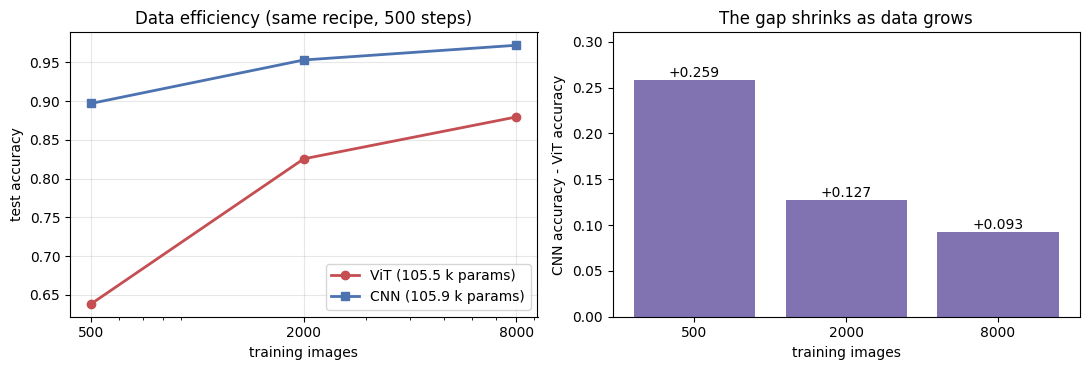

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
acc_v = [results[('ViT', n)]['acc'] for n in sizes]
acc_c = [results[('CNN', n)]['acc'] for n in sizes]
axes[0].plot(sizes, acc_v, 'o-', color='#C44E52', lw=2, label='ViT (105.5 k params)')
axes[0].plot(sizes, acc_c, 's-', color='#4C72B0', lw=2, label='CNN (105.9 k params)')
axes[0].set_xscale('log'); axes[0].set_xticks(sizes); axes[0].set_xticklabels(sizes)
axes[0].set_xlabel('training images'); axes[0].set_ylabel('test accuracy')
axes[0].set_title('Data efficiency (same recipe, 500 steps)'); axes[0].legend(); axes[0].grid(alpha=0.3)
gap = [c - v for v, c in zip(acc_v, acc_c)]
axes[1].bar([str(s) for s in sizes], gap, color='#8172B2')
for i, g in enumerate(gap):
    axes[1].text(i, g, f'{g:+.3f}', ha='center', va='bottom')
axes[1].set_xlabel('training images'); axes[1].set_ylabel('CNN accuracy - ViT accuracy')
axes[1].set_title('The gap shrinks as data grows'); axes[1].margins(y=0.2)
plt.tight_layout(); plt.show()

### Widget 2: training-set size versus accuracy

Choose the training-set size. The left panel shows the two training-loss curves for that size and the right panel the two test accuracies. All six runs are precomputed; the widget only indexes them. With 500 images both models drive the training loss to almost zero (they memorize the set), yet the ViT loses far more accuracy on the test set than the CNN: that is the missing inductive bias, measured.

In [20]:
def data_size_explorer(n_train=2000):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for name, col in [('ViT', '#C44E52'), ('CNN', '#4C72B0')]:
        r = results[(name, n_train)]
        l = np.convolve(np.array(r['losses']), np.ones(10) / 10, mode='valid')
        axes[0].plot(np.arange(len(l)) + 10, l, color=col, lw=2, label=f'{name} (train acc {r["train_acc"]:.3f})')
    axes[0].set_yscale('log'); axes[0].set_xlabel('optimizer step'); axes[0].set_ylabel('training loss')
    axes[0].set_title(f'{n_train} training images'); axes[0].legend(); axes[0].grid(alpha=0.3)
    accs = [results[('ViT', n_train)]['acc'], results[('CNN', n_train)]['acc']]
    bars = axes[1].bar(['ViT', 'CNN'], accs, color=['#C44E52', '#4C72B0'])
    for b, a in zip(bars, accs):
        axes[1].text(b.get_x() + b.get_width() / 2, a, f'{a:.3f}', ha='center', va='bottom')
    axes[1].set_ylim(0, 1.08); axes[1].set_ylabel('test accuracy (2000 images)')
    axes[1].set_title(f'gap = {accs[1] - accs[0]:+.3f}')
    plt.tight_layout(); plt.show()

interact(data_size_explorer, n_train=Dropdown(options=sizes, value=2000, description='train imgs'));

interactive(children=(Dropdown(description='train imgs', index=1, options=(500, 2000, 8000), value=2000), Outp…

## 6. Looking inside the trained ViT

A ViT is unusually transparent: every layer hands us an explicit $(N+1) \times (N+1)$ matrix saying which token looked at which. Two views are standard.

**Class-token attention.** Row 0 of the attention matrix of head $h$ in layer $\ell$ is the distribution over the 49 patches (plus itself) that the class token used to build its representation. Reshaped to $7 \times 7$ and upsampled, it is a heat map over the image.

**Attention rollout** (*Abnar and Zuidema, ACL 2020*). Attention in layer 3 acts on tokens that already mix information from layers 1 and 2, so a single layer's map is not "where the classifier looked". Rollout follows the information flow through the residual connections: in every layer average the heads, add the identity for the skip path, renormalize the rows, and multiply the matrices from the input up,

$$\tilde{A}_\ell = \tfrac12 \left(\bar{A}_\ell + I\right), \qquad R_L = \tilde{A}_L \tilde{A}_{L-1} \cdots \tilde{A}_1 ,$$

then read the class-token row of $R_L$. We compute both for 12 test images once, and every widget below only indexes the arrays.

attention array (images, layers, heads, tokens, tokens): (12, 3, 4, 50, 50)
predictions: [7, 2, 1, 0, 4, 1, 4, 9, 8, 9, 0, 6]
labels     : [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6]
rollout matrix (50, 50): finite True, rows sum to 1: True


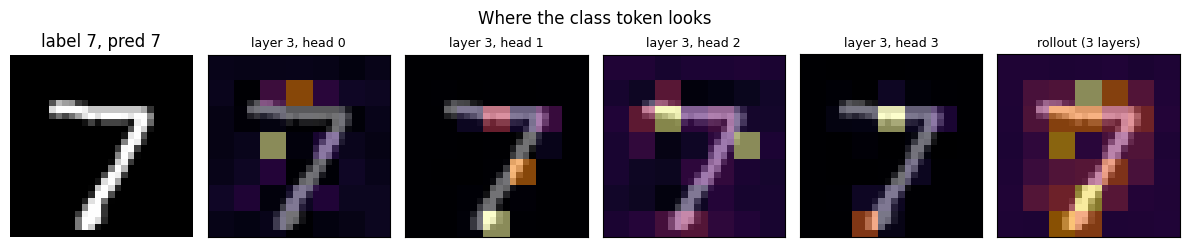

In [21]:
vit8k = models[('ViT', 8000)].eval()
probe_x, probe_y = Xte[:12], Yte[:12]
with torch.no_grad():
    logits, attn_layers = vit8k(probe_x.to(device), return_attn=True)
attn_np = np.stack([a.detach().cpu().numpy() for a in attn_layers], axis=1)     # (12, L, heads, 50, 50)
pred_np = logits.argmax(1).cpu().numpy()
print('attention array (images, layers, heads, tokens, tokens):', attn_np.shape)
print('predictions:', pred_np.tolist())
print('labels     :', probe_y.tolist())

def attention_rollout(A, upto=None):
    """Rollout of attention matrices A (L, heads, T, T) through the first `upto` layers. Returns (T, T) as numpy.

    The products are done in torch (float64): on some platforms numpy's matmul emits spurious
    overflow warnings once torch has been imported, and the result is the same to 1e-9.
    """
    A = torch.as_tensor(np.asarray(A), dtype=torch.float64)
    L = A.shape[0] if upto is None else upto
    T = A.shape[-1]
    I = torch.eye(T, dtype=torch.float64)
    R = I.clone()
    for l in range(L):
        Al = 0.5 * (A[l].mean(0) + I)               # average heads, add the residual path
        Al = Al / Al.sum(-1, keepdim=True)          # renormalize rows
        R = Al @ R                                  # this layer acts on the flow so far
    return R.numpy()

def cls_map(row):
    """Class-token attention row (50,) -> 7x7 map over the patches (the cls->cls entry is dropped)."""
    return row[1:].reshape(7, 7)

def show_map(ax, img, m, title):
    ax.imshow(img, cmap='gray')
    ax.imshow(np.kron(m, np.ones((4, 4))), cmap='inferno', alpha=0.55, vmin=0)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

R0 = attention_rollout(attn_np[0])
print(f'rollout matrix {R0.shape}: finite {np.isfinite(R0).all()}, rows sum to 1: {np.allclose(R0.sum(-1), 1)}')

i = 0
fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
axes[0].imshow(probe_x[i, 0], cmap='gray'); axes[0].set_title(f'label {probe_y[i].item()}, pred {pred_np[i]}'); axes[0].axis('off')
for h in range(4):
    show_map(axes[h + 1], probe_x[i, 0].numpy(), cls_map(attn_np[i, 2, h, 0]), f'layer 3, head {h}')
show_map(axes[5], probe_x[i, 0].numpy(), cls_map(attention_rollout(attn_np[i])[0]), 'rollout (3 layers)')
plt.suptitle('Where the class token looks'); plt.tight_layout(); plt.show()

### Widget 3: attention head viewer

Choose a test image, a layer and a head (or the mean over heads). The heat map is the class token's attention row, on top of the digit. Compare heads within one layer: they often split the work, one following the stroke, another watching the background. Then compare the last layer with the rollout: the rollout is smoother because it credits every path through the residual stack.

In [22]:
def head_viewer(image=0, layer=3, head='mean'):
    A = attn_np[image, layer - 1]
    m = A.mean(0)[0] if head == 'mean' else A[int(head)][0]
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(probe_x[image, 0], cmap='gray'); axes[0].axis('off')
    axes[0].set_title(f'label {probe_y[image].item()}, predicted {pred_np[image]}')
    show_map(axes[1], probe_x[image, 0].numpy(), cls_map(m), f'layer {layer}, head {head}\n(cls -> cls weight {m[0]:.2f})')
    show_map(axes[2], probe_x[image, 0].numpy(), cls_map(attention_rollout(attn_np[image])[0]), 'rollout, all layers')
    plt.tight_layout(); plt.show()

interact(head_viewer,
         image=IntSlider(min=0, max=11, value=0, description='test image', continuous_update=False),
         layer=IntSlider(min=1, max=3, value=3, description='layer'),
         head=Dropdown(options=['mean', '0', '1', '2', '3'], value='mean', description='head'));

interactive(children=(IntSlider(value=0, continuous_update=False, description='test image', max=11), IntSlider…

### 6.a What the position embeddings learned

The position embeddings started as random vectors. Nothing told the model that patch 8 is next to patch 9 and above patch 15. The ViT paper (its figure 7) checks whether the model figured this out by computing the **cosine similarity between the embedding of every patch and every other patch**. Rows of a $7 \times 7$ grid of $7 \times 7$ maps: the map at grid position $(i, j)$ shows how similar patch $(i, j)$'s embedding is to all 49. If positions were learned, each map should light up around its own position and along its row and column. We also measure it: the mean similarity to the four immediate neighbours against the mean similarity to everything else.

mean cosine similarity to the 4 neighbours : 0.232
mean cosine similarity to all other patches: 0.047


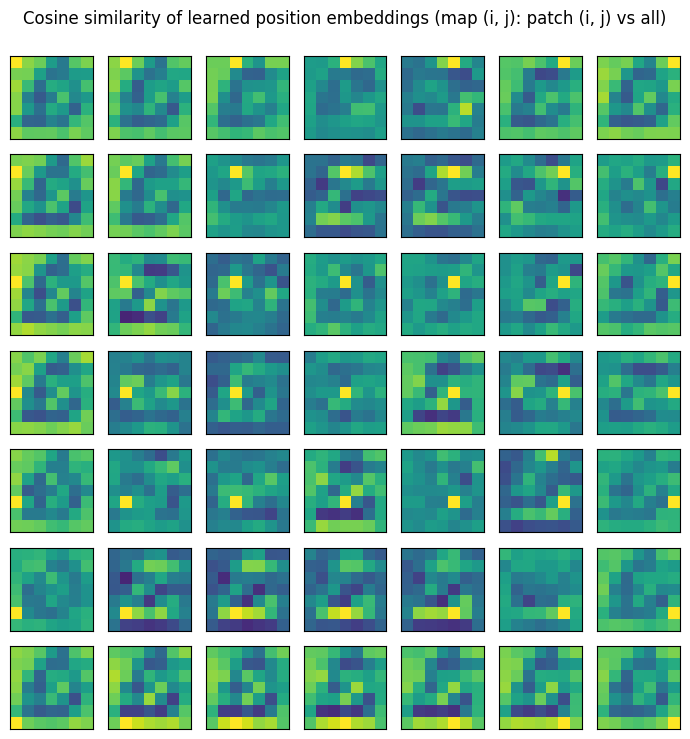

In [23]:
pos = vit8k.pos.detach().cpu()[0, 1:]                     # (49, D), the patch positions (cls dropped)
pos_n = pos / pos.norm(dim=1, keepdim=True)
sim = (pos_n @ pos_n.T).numpy()                            # (49, 49) cosine similarities
sim_grid = sim.reshape(7, 7, 7, 7)                         # [i, j] -> 7x7 map for patch (i, j)

neigh, other = [], []
for i in range(7):
    for j in range(7):
        for (a, b) in [(i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)]:
            if 0 <= a < 7 and 0 <= b < 7:
                neigh.append(sim_grid[i, j, a, b])
        mask = np.ones((7, 7), bool); mask[i, j] = False
        for (a, b) in [(i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)]:
            if 0 <= a < 7 and 0 <= b < 7: mask[a, b] = False
        other.append(sim_grid[i, j][mask].mean())
print(f'mean cosine similarity to the 4 neighbours : {np.mean(neigh):.3f}')
print(f'mean cosine similarity to all other patches: {np.mean(other):.3f}')

fig, axes = plt.subplots(7, 7, figsize=(7, 7.4))
for i in range(7):
    for j in range(7):
        axes[i, j].imshow(sim_grid[i, j], cmap='viridis', vmin=-1, vmax=1)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
plt.suptitle('Cosine similarity of learned position embeddings (map (i, j): patch (i, j) vs all)', y=0.995)
plt.tight_layout(); plt.show()

### Widget 4: position-embedding similarity

Choose a patch by row and column. The map shows the cosine similarity of that patch's learned position embedding to the other 48, with the chosen patch outlined. Move along a row and watch the bright spot follow you: the model has reconstructed the 2D layout of the image from nothing but co-occurrence statistics of pixels.

In [24]:
def pos_sim_explorer(row=3, col=3):
    m = sim_grid[row, col]
    fig, ax = plt.subplots(figsize=(4.6, 4))
    im = ax.imshow(m, cmap='viridis', vmin=-1, vmax=1)
    ax.add_patch(mpatches.Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor='red', lw=2))
    ax.set_xticks(range(7)); ax.set_yticks(range(7)); plt.colorbar(im, ax=ax, fraction=0.046)
    order = np.argsort(-m.ravel())[1:4]
    ax.set_title(f'patch ({row}, {col}): most similar patches {[divmod(int(k), 7) for k in order]}', fontsize=9)
    plt.tight_layout(); plt.show()

interact(pos_sim_explorer, row=IntSlider(min=0, max=6, value=3, description='row'),
         col=IntSlider(min=0, max=6, value=3, description='col'));

interactive(children=(IntSlider(value=3, description='row', max=6), IntSlider(value=3, description='col', max=…

## 7. Improving ViT: regularization, augmentation and distillation

The slide on "Improving Vision Transformer Performance" summarizes *Steiner et al., TMLR 2022* ("How to train your ViT?"): since a ViT has little inductive bias, it needs either more data or more **regularization and augmentation** to stand in for data. The list on the slide:

| Family | Technique | What it does |
|---|---|---|
| Regularization | **weight decay** | shrinks the weights (AdamW applies it decoupled from the gradient) |
| Regularization | **stochastic depth** | drops whole residual branches at random during training, so the depth is effectively random |
| Regularization | **dropout** in the FFN (MLP) layers | the usual unit dropout, applied only inside the MLP |
| Augmentation | **MixUp** | trains on convex combinations of pairs of images and of their labels |
| Augmentation | **RandAugment** | applies a random sequence of strong geometric and color operations |

Their finding is that with enough of this, a ViT pre-trained on the public ImageNet-21k matches or beats the same model pre-trained on JFT-300M, an order of magnitude more (and private) data. Our 500-step runs are far too short for these to help (regularization slows fitting first and pays back later), so this notebook states them and leaves them to the exercises.

### 7.a DeiT: a distillation token

*Touvron et al., ICML 2021* ("Training data-efficient image transformers and distillation through attention", DeiT) take a different route:

> "From a trained teacher model (large CNN), train student model (ViT) using standard cross-entropy loss AND KL Divergence loss with teacher outputs."

The trick is a second learnable token, the **distillation token**, appended next to the class token. Both run through the same encoder; the class token's output is trained with cross-entropy against the label, the distillation token's output with a KL divergence against the teacher's softened prediction,

$$\mathcal{L} = (1 - \lambda)\, \text{CE}(\psi(z_{\text{cls}}), y) + \lambda\, \tau^2\, \text{KL}\!\left(\psi(z_t / \tau)\ \|\ \psi(z_{\text{dist}} / \tau)\right),$$

and at test time the two heads' softmax outputs are added (we average them, which has the same argmax). DeiT's headline number uses **hard distillation**: cross-entropy against the teacher's argmax label $y_t$ in place of the KL term. The paper found that the soft KL version gave no gain at 300 epochs (81.8 to 81.8 top-1 for DeiT-B on ImageNet), hard distillation 83.0, and the distillation token plus hard distillation 83.4, the teacher being a RegNet CNN. The slide's 77.9 is ViT-B trained on ImageNet-1k with the original ViT recipe; the DeiT recipe alone lifts it to 81.8 and distillation to 83.4. Either way the CNN's inductive bias flows into the ViT through the teacher's labels.

`DistilledViT` adds the token and the second head to `TinyViT`; `train_model` knows both losses (`hard=False` for the KL term on the slide, `hard=True` for the paper's cross-entropy against the teacher's argmax). The teacher is our CNN trained on 8000 images, the student trains on the **2000-image subset**, so it can be compared with the plain ViT on the same 2000 images from section 5. We train one student with each loss.

In [25]:
class DistilledViT(TinyViT):
    """TinyViT with a DeiT distillation token and a second head."""
    def __init__(self, **kw):
        super().__init__(**kw)
        D = self.pos.shape[-1]
        self.dist = nn.Parameter(torch.zeros(1, 1, D))
        self.pos = nn.Parameter(torch.cat([self.pos.data, torch.randn(1, 1, D) * 0.02], dim=1))   # one more position
        self.head_dist = nn.Linear(D, self.head.out_features)

    def forward(self, x):
        B = x.shape[0]
        t = self.embed(x).flatten(2).transpose(1, 2)
        t = torch.cat([self.cls.expand(B, -1, -1), self.dist.expand(B, -1, -1), t], dim=1) + self.pos
        for blk in self.blocks:
            t, _ = blk(t)
        t = self.ln(t)
        logits_cls, logits_dist = self.head(t[:, 0]), self.head_dist(t[:, 1])
        if self.training:
            return logits_cls, logits_dist          # two losses during training
        return 0.5 * (logits_cls.softmax(-1) + logits_dist.softmax(-1))   # DeiT adds the two softmax outputs at test time

teacher = models[('CNN', 8000)].eval()
set_seed(0); student = DistilledViT()
print(f'DistilledViT parameters: {count_params(student):,}  (+{count_params(student) - n_vit} over TinyViT: token, position, head)')
print('DeiT student on 2000 images, CNN-8000 teacher (tau = 1, lambda = 0.5)')
losses_deit, secs = train_model(student, Xtr[:2000], Ytr[:2000], teacher=teacher, tau=1.0, lam=0.5, log_every=250)
acc_deit = accuracy(student, Xte, Yte)
print(f'  -> test accuracy {acc_deit:.4f}')

DistilledViT parameters: 106,324  (+778 over TinyViT: token, position, head)
DeiT student on 2000 images, CNN-8000 teacher (tau = 1, lambda = 0.5)


  step  250  loss 0.9805  lr 1.17e-03    7.8 s


  step  500  loss 0.0630  lr 0.00e+00   15.6 s
  -> test accuracy 0.8310


In [26]:
set_seed(0); student_hard = DistilledViT()
print('DeiT student on 2000 images, CNN-8000 teacher, hard distillation (CE against the teacher argmax)')
losses_hard, secs = train_model(student_hard, Xtr[:2000], Ytr[:2000], teacher=teacher, hard=True, lam=0.5, log_every=250)
acc_hard = accuracy(student_hard, Xte, Yte)
base = results[("ViT", 2000)]["acc"]
print(f'\n{"model (2000 training images)":40s} test accuracy')
print(f'{"teacher CNN (trained on 8000)":40s} {results[("CNN", 8000)]["acc"]:.4f}')
print(f'{"ViT, cross-entropy only":40s} {base:.4f}')
print(f'{"DistilledViT, CE + KL to teacher (soft)":40s} {acc_deit:.4f}   ({acc_deit - base:+.4f})')
print(f'{"DistilledViT, CE + CE to teacher argmax (hard)":40s} {acc_hard:.4f}   ({acc_hard - base:+.4f})')

DeiT student on 2000 images, CNN-8000 teacher, hard distillation (CE against the teacher argmax)


  step  250  loss 0.9790  lr 1.17e-03    7.7 s


  step  500  loss 0.0485  lr 0.00e+00   15.5 s

model (2000 training images)             test accuracy
teacher CNN (trained on 8000)            0.9720
ViT, cross-entropy only                  0.8255
DistilledViT, CE + KL to teacher (soft)  0.8310   (+0.0055)
DistilledViT, CE + CE to teacher argmax (hard) 0.8290   (+0.0035)


Read the numbers for what they are. Both students are 106 k parameters, see 2,000 images 32 times, and, as the training accuracies in section 5 showed, memorize them: on the training images the teacher's labels, soft or hard, carry nearly the same information as the ground truth, so neither distillation term has much room to add, and both students land within half a point of the plain ViT. DeiT's gains came from 300 epochs with heavy augmentation, where every view of every image is new and the teacher's opinion of it is genuinely extra signal. The code is the same; the data regime is not. Exercise 4 asks you to add the augmentation and re-measure.

## 8. Isotropic versus hierarchical

The "ViT vs CNN" slides make a structural point:

> "In most CNNs (including ResNets), resolution decreases and number of channels increases as we go deep into the network (Hierarchical architecture). This is useful since objects can occur in multiple scales."
>
> "In a ViT, all blocks have same resolution and number of channels (Isotropic architecture). Can we build a hierarchical ViT model?"

Our two trained models show it directly: the CNN's feature map goes $28 \to 14 \to 7$ in resolution while its channels go $1 \to 16 \to 32$; the ViT keeps 49 tokens of width 64 from the first block to the last. Every ViT block costs the same and sees the image at the same scale, which is wasteful for large images and awkward for dense tasks (detection, segmentation) that want a feature pyramid.

CNN (hierarchical):
  input    channels   1  resolution 28x28
  stage 1  channels  16  resolution 14x14
  stage 2  channels  32  resolution 7x7
ViT (isotropic):
  tokens   channels  64  resolution 7x7 (49 tokens)
  block 1  channels  64  resolution 7x7 (49 tokens)
  block 2  channels  64  resolution 7x7 (49 tokens)
  block 3  channels  64  resolution 7x7 (49 tokens)


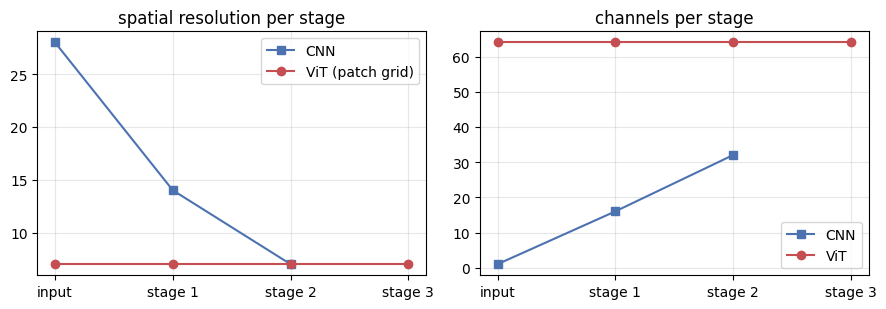

In [27]:
cnn8k = models[('CNN', 8000)].eval()
xb = Xte[:1].to(device)
with torch.no_grad():
    f1 = cnn8k.stage1(xb); f2 = cnn8k.stage2(f1)
print('CNN (hierarchical):')
for name, t in [('input', xb), ('stage 1', f1), ('stage 2', f2)]:
    print(f'  {name:8s} channels {t.shape[1]:3d}  resolution {t.shape[2]}x{t.shape[3]}')
print('ViT (isotropic):')
for name in ['tokens', 'block 1', 'block 2', 'block 3']:
    print(f'  {name:8s} channels  64  resolution 7x7 (49 tokens)')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
stages = ['input', 'stage 1', 'stage 2', 'stage 3']
axes[0].plot(stages[:3], [28, 14, 7], 's-', color='#4C72B0', label='CNN')
axes[0].plot(stages, [7, 7, 7, 7], 'o-', color='#C44E52', label='ViT (patch grid)')
axes[0].set_title('spatial resolution per stage'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(stages[:3], [1, 16, 32], 's-', color='#4C72B0', label='CNN')
axes[1].plot(stages, [64, 64, 64, 64], 'o-', color='#C44E52', label='ViT')
axes[1].set_title('channels per stage'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Swin Transformer

*Liu et al., ICCV 2021* ("Swin Transformer: Hierarchical Vision Transformer using Shifted Windows") answers the question with three ideas, each of which we now build and verify:

1. **Patch partition and linear embedding, then patch merging** between stages: $4 \times 4$ patches to start (not 16), so many tokens at high resolution, and a merging step that halves the resolution and doubles the channels, giving the CNN-like pyramid of stages.
2. **Window attention**: attention inside $M \times M$ windows of tokens, so the cost is linear in the image size.
3. **Shifted windows** every other block, so information crosses window borders, implemented with a cyclic shift and a mask.

### 9.a Patch partition and linear embedding

Nothing new: the slide's "patch partition" is `patchify` with $P = 4$, and "linear embedding" is the linear projection of section 2 to $C$ channels ($C = 96$ in Swin-T; we use 32). From here on a feature map is a tensor of shape `(B, H, W, C)`: a grid of tokens.

In [28]:
set_seed(0)
C_swin = 32
img = torch.randn(2, 3, 64, 64)                            # a 64 x 64 RGB image
embed = nn.Linear(3 * 4 * 4, C_swin)
tokens = embed(patchify(img, 4))                           # (B, 256, C)
H = W = 64 // 4
grid = tokens.view(2, H, W, C_swin)                        # tokens on their grid
print('image', tuple(img.shape), '-> patch partition', tuple(patchify(img, 4).shape),
      '-> linear embedding', tuple(tokens.shape), '-> grid', tuple(grid.shape))

image (2, 3, 64, 64) -> patch partition (2, 256, 48) -> linear embedding (2, 256, 32) -> grid (2, 16, 16, 32)


### 9.b Window attention

> "Problem: With $H \times W$ grid of tokens, attention matrices are of size $H^2W^2$, which is quadratic in image size. Solution: Window Attention. Instead of allowing each token to attend to all other tokens in the image, divide image into windows of $M \times M$ tokens and compute attention within each window. Now the attention matrices are of size $M^2HW$, which is linear in image size for a fixed $M$. Swin uses $M = 7$ throughout the network."

Implementation is a reshape: `window_partition` turns `(B, H, W, C)` into `(B * nW, M*M, C)`, ordinary attention runs on that batch of short sequences, and `window_reverse` puts the tokens back. To check it we compute the *same thing the slow way*: global attention over all $HW$ tokens with an additive mask that forbids every pair of tokens that are not in the same window. The two must agree exactly.

In [29]:
def window_partition(x, M):
    """(B, H, W, C) -> (B * nW, M*M, C): each M x M window becomes one short sequence."""
    B, H, W, C = x.shape
    x = x.view(B, H // M, M, W // M, M, C).permute(0, 1, 3, 2, 4, 5)
    return x.reshape(-1, M * M, C)

def window_reverse(w, M, H, W):
    """Inverse of window_partition: (B * nW, M*M, C) -> (B, H, W, C)."""
    B = w.shape[0] // ((H // M) * (W // M))
    x = w.view(B, H // M, W // M, M, M, -1).permute(0, 1, 3, 2, 4, 5)
    return x.reshape(B, H, W, -1)

def window_attention(x, attn, M, mask=None):
    """Attention within M x M windows of the token grid x (B, H, W, C), using the Attention module `attn`."""
    B, H, W, C = x.shape
    out, _ = attn(window_partition(x, M), mask)
    return window_reverse(out, M, H, W)

def masked_global_attention(x, attn, group_id):
    """Reference: global attention over all H*W tokens, masked so a token only attends within its group."""
    B, H, W, C = x.shape
    g = group_id.flatten()
    mask = torch.where(g[:, None] == g[None, :], 0.0, -1e9)          # (HW, HW) additive mask
    out, _ = attn(x.reshape(B, H * W, C), mask)
    return out.view(B, H, W, C)

set_seed(0)
attn_swin = Attention(C_swin, heads=4)
M = 4
rows, cols = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
window_id = (rows // M) * (W // M) + cols // M                        # which window each token is in

x_round = window_reverse(window_partition(grid, M), M, H, W)
assert torch.equal(x_round, grid)
y_win = window_attention(grid, attn_swin, M)
y_ref = masked_global_attention(grid, attn_swin, window_id)
assert torch.allclose(y_win, y_ref, atol=1e-5)
print(f'grid {tuple(grid.shape)} -> {(H//M)*(W//M)} windows of {M}x{M} = {M*M} tokens each')
print('window_partition -> window_reverse is the identity:', torch.equal(x_round, grid))
print(f'window attention == global attention with a block mask: max |diff| = {maxdiff(y_win, y_ref):.1e}')
print(f'attention matrices: windowed {(H//M)*(W//M)} x ({M*M} x {M*M}) = {(H//M)*(W//M)*M**4:,} entries;'
      f' global {H*W} x {H*W} = {(H*W)**2:,} entries')

grid (2, 16, 16, 32) -> 16 windows of 4x4 = 16 tokens each
window_partition -> window_reverse is the identity: True
window attention == global attention with a block mask: max |diff| = 0.0e+00
attention matrices: windowed 16 x (16 x 16) = 4,096 entries; global 256 x 256 = 65,536 entries


### 9.c The complexity, measured

The Swin paper writes the cost of one attention layer on an $h \times w$ token grid with $C$ channels as

$$\Omega(\text{MSA}) = 4hwC^2 + 2(hw)^2 C, \qquad \Omega(\text{W-MSA}) = 4hwC^2 + 2M^2 hw\, C .$$

The first term (Q, K, V and output projections) is the same in both; the second is the attention itself, quadratic in $hw$ for global attention and linear for windows. We check both formulas against `FlopCounterMode` on our `Attention` module (it reports $2\times$ multiply-accumulates), then time the two on growing grids.

  grid  tokens   global MACs   counted/2  window MACs   counted/2  t_global  t_window
  8x8       64       524,288     524,288      524,288     524,288     0.1ms     0.1ms
 16x16     256     5,242,880   5,242,880    2,097,152   2,097,152     0.2ms     0.1ms
 24x24     576    23,592,960  23,592,960    4,718,592   4,718,592     0.6ms     0.3ms
 32x32    1024    71,303,168  71,303,168    8,388,608   8,388,608     2.1ms     0.4ms
 48x48    2304   349,175,808 349,175,808   18,874,368  18,874,368     9.6ms     0.8ms
formulas == FlopCounterMode for every grid (M = 8, C = 32)


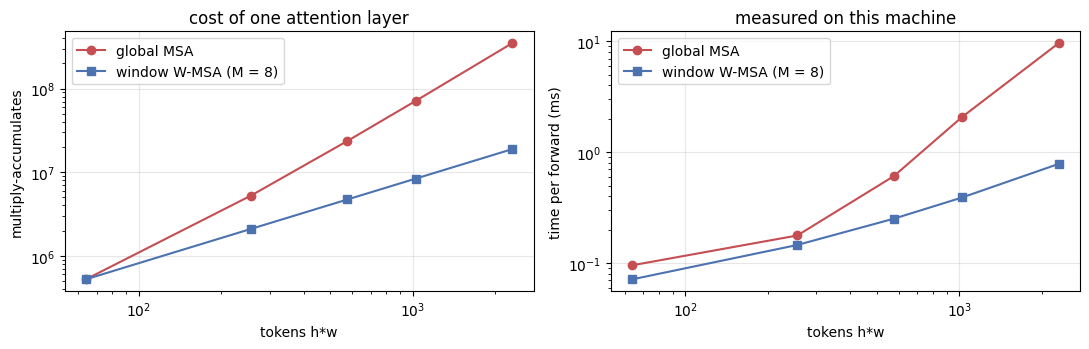

In [30]:
def msa_macs(h, w, C):
    return 4 * h * w * C * C + 2 * (h * w) ** 2 * C

def wmsa_macs(h, w, C, M):
    return 4 * h * w * C * C + 2 * M * M * h * w * C

def measured_flops(fn):
    with FlopCounterMode(display=False) as fc:
        fn()
    return fc.get_total_flops()

grids = [8, 16, 24, 32, 48]
rows_out = []
print(f'{"grid":>6} {"tokens":>7} {"global MACs":>13} {"counted/2":>11} {"window MACs":>12} {"counted/2":>11} {"t_global":>9} {"t_window":>9}')
for g in grids:
    xg = torch.randn(1, g, g, C_swin)
    f_glob = measured_flops(lambda: attn_swin(xg.view(1, g * g, C_swin))) // 2
    f_win = measured_flops(lambda: window_attention(xg, attn_swin, 8)) // 2
    assert f_glob == msa_macs(g, g, C_swin) and f_win == wmsa_macs(g, g, C_swin, 8)
    with torch.no_grad():
        t0 = time.perf_counter()
        for _ in range(3): attn_swin(xg.view(1, g * g, C_swin))
        t_glob = (time.perf_counter() - t0) / 3
        t0 = time.perf_counter()
        for _ in range(3): window_attention(xg, attn_swin, 8)
        t_win = (time.perf_counter() - t0) / 3
    rows_out.append((g, f_glob, f_win, t_glob, t_win))
    print(f'{g:>3}x{g:<2} {g*g:>7} {msa_macs(g, g, C_swin):>13,} {f_glob:>11,} {wmsa_macs(g, g, C_swin, 8):>12,} {f_win:>11,} {t_glob*1e3:>7.1f}ms {t_win*1e3:>7.1f}ms')
print('formulas == FlopCounterMode for every grid (M = 8, C = 32)')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
toks = [r[0] ** 2 for r in rows_out]
axes[0].plot(toks, [r[1] for r in rows_out], 'o-', color='#C44E52', label='global MSA')
axes[0].plot(toks, [r[2] for r in rows_out], 's-', color='#4C72B0', label='window W-MSA (M = 8)')
axes[0].set_xscale('log'); axes[0].set_yscale('log'); axes[0].set_xlabel('tokens h*w'); axes[0].set_ylabel('multiply-accumulates')
axes[0].set_title('cost of one attention layer'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(toks, [r[3] * 1e3 for r in rows_out], 'o-', color='#C44E52', label='global MSA')
axes[1].plot(toks, [r[4] * 1e3 for r in rows_out], 's-', color='#4C72B0', label='window W-MSA (M = 8)')
axes[1].set_xscale('log'); axes[1].set_yscale('log'); axes[1].set_xlabel('tokens h*w'); axes[1].set_ylabel('time per forward (ms)')
axes[1].set_title('measured on this machine'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Widget 5: global versus window attention cost

Drag the grid size and pick a window size. The bars are the two formulas; the title gives the ratio. At $56 \times 56$ tokens (Swin's first stage on a $224 \times 224$ image) with $M = 7$ and $C = 96$, global attention would spend almost all of its budget on the $2(hw)^2C$ term; window attention makes that term $64 \times$ smaller. At small grids the two are close, which is why Swin's last stage ($7 \times 7$ tokens, $M = 7$) is simply global attention.

In [31]:
def complexity_explorer(grid=56, M=7, C=96):
    g_proj, g_attn = 4 * grid * grid * C * C, 2 * (grid * grid) ** 2 * C
    w_attn = 2 * M * M * grid * grid * C
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.bar(['global MSA', 'window W-MSA'], [g_proj, g_proj], color='#999999', label='projections 4hwC^2')
    ax.bar(['global MSA', 'window W-MSA'], [g_attn, w_attn], bottom=[g_proj, g_proj], color=['#C44E52', '#4C72B0'],
           label='attention term')
    for i, tot in enumerate([g_proj + g_attn, g_proj + w_attn]):
        ax.text(i, tot, f'{tot/1e9:.2f} GMAC', ha='center', va='bottom')
    ax.set_ylabel('multiply-accumulates'); ax.margins(y=0.25); ax.legend(loc='upper right')
    ax.set_title(f'{grid}x{grid} tokens, C = {C}, M = {M}: global / window = {(g_proj+g_attn)/(g_proj+w_attn):.1f}x, '
                 f'attention term {(grid*grid)/(M*M):.0f}x smaller')
    plt.tight_layout(); plt.show()

interact(complexity_explorer,
         grid=IntSlider(min=7, max=112, step=7, value=56, description='grid h = w'),
         M=Dropdown(options=[4, 7, 14], value=7, description='window M'),
         C=Dropdown(options=[32, 96, 192, 384], value=96, description='channels C'));

interactive(children=(IntSlider(value=56, description='grid h = w', max=112, min=7, step=7), Dropdown(descript…

### 9.d Shifted windows: cyclic shift and the mask

> "Problem: With window attention, there is no communication between windows, restricting the flow of information across different regions of the image. Solution: Shifted Window Attention. Shift the attention windows progressively across the image."

Swin alternates two kinds of block. In a **W-MSA** block the windows start at the top-left corner. In the next, **SW-MSA**, block the window grid is displaced by $s = \lfloor M/2 \rfloor$ tokens in both directions, so every window of the second block straddles four windows of the first, and after two blocks every token has exchanged information with tokens up to $2M$ away. Stacking this, the receptive field grows across the whole image.

The displaced grid has an awkward shape: $3 \times 3$ windows of different sizes instead of $2 \times 2$ equal ones on an $8 \times 8$ grid with $M = 4$, so it cannot be batched with a reshape. Swin's trick (the "Shifted Window Attention" slide):

1. **Cyclic shift** the token grid up and to the left by $s$ (`torch.roll`), so the small border pieces wrap around to the bottom-right and the displaced windows become regular $M \times M$ windows again.
2. Some of those regular windows now contain pieces that were far apart in the image (a piece from the top wrapped next to a piece from the bottom). A **mask** forbids attention between pieces that do not belong to the same displaced window.
3. Run ordinary window attention with the mask, then **roll back**.

The reference we test against is the definition itself: global attention over all tokens with a mask that allows exactly the pairs in the same *displaced* window, computed in the original (unrolled) coordinates as $\lfloor (r + M - s)/M \rfloor$ and $\lfloor (c + M - s)/M \rfloor$. If the roll-and-mask trick is right, the two are equal to floating-point precision, for every window size and shift.

In [32]:
def swin_shift_mask(H, W, M, s):
    """Swin's attention mask for shifted windows after a cyclic shift by (-s, -s).

    Returns (nW, M*M, M*M) with 0 where two tokens came from the same displaced window and -1e9 elsewhere.
    """
    region = torch.zeros(1, H, W, 1)
    k = 0
    for hs in (slice(0, -M), slice(-M, -s), slice(-s, None)):        # rows: main body, wrapped strip, wrapped corner
        for ws in (slice(0, -M), slice(-M, -s), slice(-s, None)):
            region[:, hs, ws, :] = k
            k += 1
    rw = window_partition(region, M).squeeze(-1)                     # (nW, M*M) region id per token
    diff = rw[:, None, :] - rw[:, :, None]
    return torch.where(diff != 0, -1e9, 0.0)

def shifted_window_attention(x, attn, M, s):
    """SW-MSA: cyclic shift, masked window attention, shift back. s = 0 gives plain W-MSA.

    As in the official Swin code, the shift is dropped when the grid is no larger than the window:
    a single window has no neighbour to connect to, and shifting it would only mask pairs out.
    """
    B, H, W, C = x.shape
    if s == 0 or min(H, W) <= M:
        return window_attention(x, attn, M)
    xs = torch.roll(x, shifts=(-s, -s), dims=(1, 2))
    mask = swin_shift_mask(H, W, M, s).repeat(B, 1, 1)[:, None]      # (B*nW, 1, M*M, M*M), broadcast over heads
    out = window_attention(xs, attn, M, mask)
    return torch.roll(out, shifts=(s, s), dims=(1, 2))

def displaced_window_id(H, W, M, s):
    """Which displaced window (grid shifted by s) each token of the ORIGINAL grid belongs to."""
    r, c = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    n_cols = W // M + (1 if s > 0 else 0)
    return ((r + M - s) // M) * n_cols + (c + M - s) // M

set_seed(0)
for (Hs, Ms, ss) in [(16, 4, 2), (16, 8, 4), (16, 4, 1), (12, 6, 3), (16, 4, 3)]:
    xg = torch.randn(2, Hs, Hs, C_swin)
    y_swin = shifted_window_attention(xg, attn_swin, Ms, ss)
    y_ref = masked_global_attention(xg, attn_swin, displaced_window_id(Hs, Hs, Ms, ss))
    assert torch.allclose(y_swin, y_ref, atol=1e-5), (Hs, Ms, ss)
    print(f'grid {Hs}x{Hs}, M = {Ms}, shift = {ss}: roll + mask == attention in the displaced windows, '
          f'max |diff| = {maxdiff(y_swin, y_ref):.1e}')
# and with no shift it is plain window attention
xg = torch.randn(2, 16, 16, C_swin)
assert torch.equal(shifted_window_attention(xg, attn_swin, 4, 0), window_attention(xg, attn_swin, 4))
print('shift = 0 reduces to W-MSA exactly')

grid 16x16, M = 4, shift = 2: roll + mask == attention in the displaced windows, max |diff| = 0.0e+00
grid 16x16, M = 8, shift = 4: roll + mask == attention in the displaced windows, max |diff| = 0.0e+00
grid 16x16, M = 4, shift = 1: roll + mask == attention in the displaced windows, max |diff| = 0.0e+00
grid 12x12, M = 6, shift = 3: roll + mask == attention in the displaced windows, max |diff| = 8.9e-08
grid 16x16, M = 4, shift = 3: roll + mask == attention in the displaced windows, max |diff| = 0.0e+00
shift = 0 reduces to W-MSA exactly


The figure draws the whole trick for an $8 \times 8$ grid. Left: the regular windows of a W-MSA block. Second: the displaced windows of the following SW-MSA block, in image coordinates (nine pieces, four sizes). Third: after the cyclic shift the pieces wrap into four regular windows again; each color is one original piece. Right: the mask for the bottom-right window, which holds four pieces: attention is allowed (yellow) only inside the diagonal blocks, so a token never sees a token that wrapped in from the other side of the image. The same four panels are drawn for three window sizes.

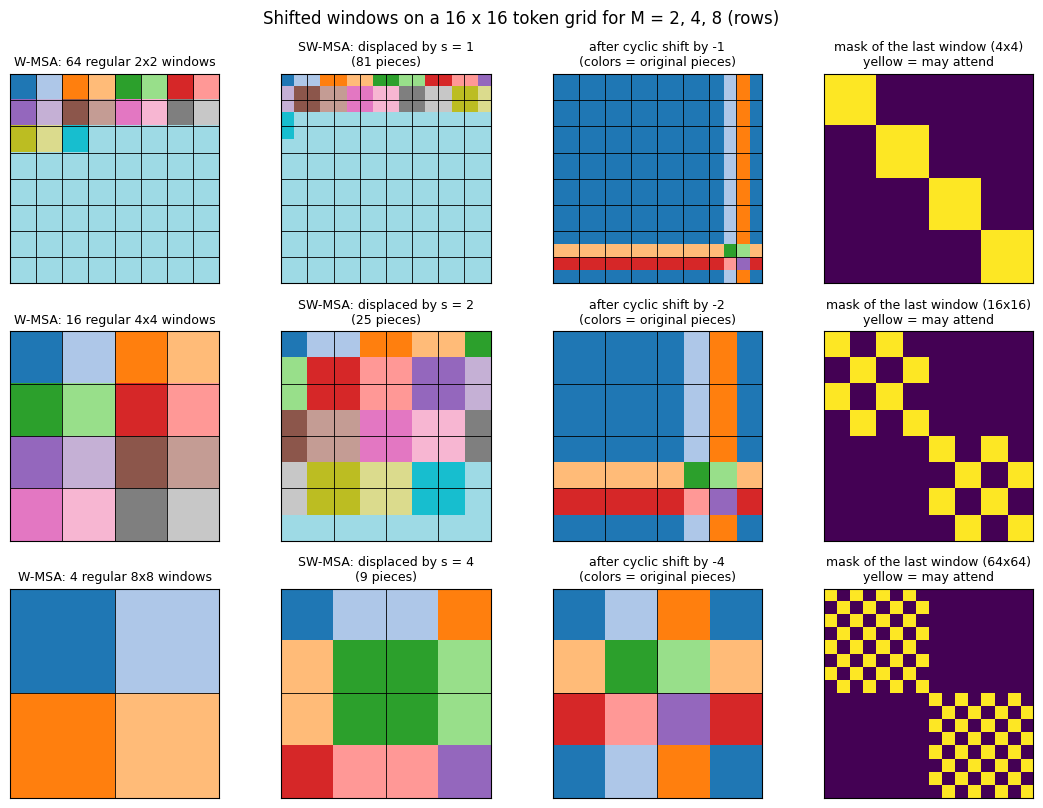

In [33]:
def draw_shift_panels(axes, H, M, s):
    """Four panels: regular windows, displaced windows, rolled regions, and the mask of the last window."""
    r, c = torch.meshgrid(torch.arange(H), torch.arange(H), indexing='ij')
    regular = ((r // M) * (H // M) + c // M).numpy()
    displaced = displaced_window_id(H, H, M, s).numpy()
    region = torch.zeros(1, H, H, 1); k = 0
    for hs in (slice(0, -M), slice(-M, -s), slice(-s, None)):
        for ws in (slice(0, -M), slice(-M, -s), slice(-s, None)):
            region[:, hs, ws, :] = k; k += 1
    rolled_region = torch.roll(region, shifts=(-s, -s), dims=(1, 2))[0, :, :, 0].numpy()
    mask = swin_shift_mask(H, H, M, s)[-1].numpy()                      # bottom-right window
    for ax, m, t in zip(axes[:3], [regular, displaced, rolled_region],
                        [f'W-MSA: {(H//M)**2} regular {M}x{M} windows', f'SW-MSA: displaced by s = {s}\n({len(np.unique(displaced))} pieces)',
                         f'after cyclic shift by -{s}\n(colors = original pieces)']):
        ax.imshow(m, cmap='tab20', vmin=0, vmax=19)
        for i in range(0, H + 1, M):
            ax.axhline(i - 0.5, color='k', lw=0.6); ax.axvline(i - 0.5, color='k', lw=0.6)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_title(t, fontsize=9)
    axes[3].imshow(mask == 0, cmap='viridis')
    axes[3].set_title(f'mask of the last window ({M*M}x{M*M})\nyellow = may attend', fontsize=9)
    axes[3].set_xticks([]); axes[3].set_yticks([])

fig, axes = plt.subplots(3, 4, figsize=(11, 8.2))
for row, (M_, s_) in enumerate([(2, 1), (4, 2), (8, 4)]):
    draw_shift_panels(axes[row], 16, M_, s_)
plt.suptitle('Shifted windows on a 16 x 16 token grid for M = 2, 4, 8 (rows)')
plt.tight_layout(); plt.show()

### Widget 6: window size and shift on or off, with the mask drawn

Pick a window size and toggle the shift. With the shift off, the displaced-window panel is identical to the regular one and the mask is all yellow (nothing to forbid). Turn the shift on and count the pieces: $(H/M + 1)^2$ of them, wrapping into $(H/M)^2$ windows, with the mask blocking exactly the cross-piece pairs. The larger the window, the larger the share of tokens that sit in a wrapped window and need the mask.

In [34]:
def shift_explorer(M=4, shift=True):
    H = 16
    s = M // 2 if shift else 0
    fig, axes = plt.subplots(1, 4, figsize=(11, 3))
    if s == 0:
        r, c = torch.meshgrid(torch.arange(H), torch.arange(H), indexing='ij')
        regular = ((r // M) * (H // M) + c // M).numpy()
        for ax, t in zip(axes[:3], [f'W-MSA: {(H//M)**2} windows', 'shift off: same windows', 'no cyclic shift needed']):
            ax.imshow(regular, cmap='tab20', vmin=0, vmax=19); ax.set_title(t, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
        axes[3].imshow(np.ones((M * M, M * M)), cmap='viridis', vmin=0, vmax=1)
        axes[3].set_title(f'mask ({M*M}x{M*M}): all allowed', fontsize=9); axes[3].set_xticks([]); axes[3].set_yticks([])
    else:
        draw_shift_panels(axes, H, M, s)
    n_masked = 0 if s == 0 else int((swin_shift_mask(H, H, M, s) != 0).sum().item())
    plt.suptitle(f'M = {M}, shift s = {s}: {n_masked:,} forbidden token pairs out of {(H//M)**2 * M**4:,}', y=1.02)
    plt.tight_layout(); plt.show()

interact(shift_explorer, M=Dropdown(options=[2, 4, 8], value=4, description='window M'),
         shift=Checkbox(value=True, description='shifted (SW-MSA)'));

interactive(children=(Dropdown(description='window M', index=1, options=(2, 4, 8), value=4), Checkbox(value=Tr…

### 9.e Relative position bias

> "What about positional embedding here? Swin does not use positional embedding! Instead, it encodes relative position between patches when computing attention using learned biases ($B \in \mathbb{R}^{M^2 \times M^2}$). Attention with relative bias defined as: $A = \text{Softmax}\!\left(\frac{QK^T}{\sqrt{D}} + B\right) V$."

Within a window, the pair (query at $(r_1, c_1)$, key at $(r_2, c_2)$) has a relative offset $(r_1 - r_2, c_1 - c_2)$ with each coordinate in $[-(M-1), M-1]$: only $(2M - 1)^2$ distinct offsets. Swin learns one bias per offset per head, a table $\hat{B} \in \mathbb{R}^{(2M-1)^2 \times h}$, and builds the $M^2 \times M^2$ matrix $B$ by indexing the table. Two pairs with the same offset share the same bias, which is the property we assert. The bias plugs into our `Attention` through its `mask` argument, since a mask is just an additive term before the softmax.

In [35]:
def relative_position_index(M):
    """(M*M, M*M) integer table: index into the (2M-1)^2 relative-offset bias table for every token pair."""
    coords = torch.stack(torch.meshgrid(torch.arange(M), torch.arange(M), indexing='ij')).flatten(1)   # (2, M*M)
    rel = (coords[:, :, None] - coords[:, None, :]).permute(1, 2, 0).contiguous()                       # (M*M, M*M, 2)
    rel[:, :, 0] += M - 1                       # shift to [0, 2M-2]
    rel[:, :, 1] += M - 1
    rel[:, :, 0] *= 2 * M - 1                   # row-major flattening of the (2M-1) x (2M-1) offset grid
    return rel.sum(-1)

class WindowAttention(nn.Module):
    """Attention inside a window with Swin's learned relative position bias B (one table per head)."""
    def __init__(self, C, heads, M):
        super().__init__()
        self.attn, self.M = Attention(C, heads), M
        self.bias_table = nn.Parameter(torch.zeros((2 * M - 1) ** 2, heads))
        nn.init.trunc_normal_(self.bias_table, std=0.02)
        self.register_buffer('rel_index', relative_position_index(M))

    def relative_bias(self):
        B = self.bias_table[self.rel_index.flatten()].view(self.M * self.M, self.M * self.M, -1)
        return B.permute(2, 0, 1)                                     # (heads, M*M, M*M)

    def forward(self, windows, mask=None):
        bias = self.relative_bias()[None]                              # (1, heads, M*M, M*M)
        return self.attn(windows, bias if mask is None else bias + mask)

M = 4
idx = relative_position_index(M)
print(f'M = {M}: {M*M}x{M*M} pairs but only {idx.unique().numel()} distinct offsets = (2M-1)^2 = {(2*M-1)**2}')
# tokens 0 and 1 are (0,0),(0,1); tokens 5 and 6 are (1,1),(1,2): same offset (0,-1), so same bias index.
assert idx[0, 1] == idx[5, 6] and idx[1, 0] != idx[0, 1]
print(f'index(0,1) = {idx[0, 1].item()} == index(5,6) = {idx[5, 6].item()} (same offset);  index(1,0) = {idx[1, 0].item()} (opposite offset)')

set_seed(0)
wattn = WindowAttention(C_swin, heads=4, M=M)
Bmat = wattn.relative_bias()
assert torch.allclose(Bmat[:, 0, 1], Bmat[:, 5, 6]) and torch.allclose(Bmat[:, 0, 1], Bmat[:, 10, 11])
print('B[h, i, j] is the same for every pair with the same offset:', tuple(Bmat.shape), 'built from a table of', tuple(wattn.bias_table.shape))
print(f'parameters: bias table {wattn.bias_table.numel()} vs an absolute position embedding for a 56x56 grid: {56*56*C_swin:,}')

M = 4: 16x16 pairs but only 49 distinct offsets = (2M-1)^2 = 49
index(0,1) = 23 == index(5,6) = 23 (same offset);  index(1,0) = 25 (opposite offset)
B[h, i, j] is the same for every pair with the same offset: (4, 16, 16) built from a table of (49, 4)
parameters: bias table 196 vs an absolute position embedding for a 56x56 grid: 100,352


### 9.f Patch merging

The slide's "Patch Merging" halves the resolution and doubles the channels between stages: take each $2 \times 2$ group of neighbouring tokens, concatenate their $C$-dimensional features into $4C$, apply a layer norm, and a linear layer $4C \to 2C$. It is the transformer's version of a strided convolution, and again literally so: the linear part of patch merging **is** a `Conv2d(C, 2C, kernel_size=2, stride=2)` with the weight columns rearranged. We check that.

In [36]:
class PatchMerging(nn.Module):
    """Swin patch merging: 2x2 neighbouring tokens -> concat (4C) -> LayerNorm -> Linear(4C, 2C)."""
    def __init__(self, C):
        super().__init__()
        self.norm = nn.LayerNorm(4 * C)
        self.reduction = nn.Linear(4 * C, 2 * C, bias=False)

    @staticmethod
    def concat_2x2(x):
        x0, x1, x2, x3 = x[:, 0::2, 0::2], x[:, 1::2, 0::2], x[:, 0::2, 1::2], x[:, 1::2, 1::2]
        return torch.cat([x0, x1, x2, x3], dim=-1)                    # (B, H/2, W/2, 4C)

    def forward(self, x):
        return self.reduction(self.norm(self.concat_2x2(x)))

set_seed(0)
merge = PatchMerging(C_swin)
y = merge(grid)
print('patch merging:', tuple(grid.shape), '->', tuple(y.shape), '(resolution / 2, channels x 2)')

# The Linear on the 2x2 concatenation is a stride-2, kernel-2 convolution.
conv2 = nn.Conv2d(C_swin, 2 * C_swin, kernel_size=2, stride=2, bias=False)
with torch.no_grad():
    for k, (kh, kw) in enumerate([(0, 0), (1, 0), (0, 1), (1, 1)]):   # the order x0, x1, x2, x3 above
        conv2.weight[:, :, kh, kw] = merge.reduction.weight[:, k * C_swin:(k + 1) * C_swin]
lin_out = merge.reduction(PatchMerging.concat_2x2(grid))
conv_out = conv2(grid.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
assert torch.allclose(lin_out, conv_out, atol=1e-5)
print(f'Linear(4C, 2C) on 2x2 groups == Conv2d(C, 2C, kernel 2, stride 2): max |diff| = {maxdiff(lin_out, conv_out):.1e}')

patch merging: (2, 16, 16, 32) -> (2, 8, 8, 64) (resolution / 2, channels x 2)
Linear(4C, 2C) on 2x2 groups == Conv2d(C, 2C, kernel 2, stride 2): max |diff| = 6.0e-07


### 9.g A tiny hierarchical Swin, end to end

The "Architecture Details" slide draws one Swin block pair: LN, **W-MSA**, residual; LN, MLP, residual; then the same with **SW-MSA**. Stages are separated by patch merging. Below we assemble a three-stage Swin on a $64 \times 64$ image with $4 \times 4$ patches: stage 1 has $16 \times 16$ tokens of width 32, stage 2 has $8 \times 8$ of width 64, stage 3 has $4 \times 4$ of width 128, with $M = 4$ windows throughout and the shifted block every second position. The shapes print the hierarchy the slides asked for. The last stage is global attention in disguise because the whole $4 \times 4$ grid is one window; like the official Swin code, `SwinBlock` drops the shift whenever the grid is no larger than the window (shifting a single window would cut it into four masked pieces and forbid most of its token pairs instead of connecting anything), so both blocks of stage 3 attend globally. The cell checks that.

In [37]:
class SwinBlock(nn.Module):
    """One Swin block: LN -> (S)W-MSA with relative bias -> residual; LN -> MLP -> residual."""
    def __init__(self, C, heads, M, shift):
        super().__init__()
        self.M, self.s = M, shift
        self.ln1, self.wattn = nn.LayerNorm(C), WindowAttention(C, heads, M)
        self.ln2 = nn.LayerNorm(C)
        self.mlp = nn.Sequential(nn.Linear(C, 4 * C), nn.GELU(), nn.Linear(4 * C, C))

    def shift_for(self, H, W):
        """Effective shift: the official code sets it to 0 whenever the grid is not larger than the window."""
        return self.s if min(H, W) > self.M else 0

    def forward(self, x):                                   # x: (B, H, W, C)
        B, H, W, C = x.shape
        s = self.shift_for(H, W)
        h = self.ln1(x)
        if s > 0:
            h = torch.roll(h, shifts=(-s, -s), dims=(1, 2))
            mask = swin_shift_mask(H, W, self.M, s).to(x.device).repeat(B, 1, 1)[:, None]
        else:
            mask = None
        out, _ = self.wattn(window_partition(h, self.M), mask)
        out = window_reverse(out, self.M, H, W)
        if s > 0:
            out = torch.roll(out, shifts=(s, s), dims=(1, 2))
        x = x + out
        return x + self.mlp(self.ln2(x))


class TinySwin(nn.Module):
    """Patch partition + linear embedding, then stages of [W-MSA block, SW-MSA block] separated by patch merging."""
    def __init__(self, C=32, heads=(2, 4, 8), M=4, depths=(2, 2, 2), n_cls=10, in_ch=3, P=4):
        super().__init__()
        self.P = P
        self.embed = nn.Linear(in_ch * P * P, C)
        self.stages, self.merges = nn.ModuleList(), nn.ModuleList()
        for i, (h, d) in enumerate(zip(heads, depths)):
            Ci = C * 2 ** i
            self.stages.append(nn.Sequential(*[SwinBlock(Ci, h, M, shift=(M // 2 if j % 2 else 0)) for j in range(d)]))
            if i < len(heads) - 1:
                self.merges.append(PatchMerging(Ci))
        self.ln = nn.LayerNorm(C * 2 ** (len(heads) - 1))
        self.head = nn.Linear(C * 2 ** (len(heads) - 1), n_cls)

    def forward(self, img, trace=False):
        B, _, Hi, Wi = img.shape
        x = self.embed(patchify(img, self.P)).view(B, Hi // self.P, Wi // self.P, -1)
        if trace: print(f'{"patch partition + embed":26s} {tuple(x.shape)}')
        for i, stage in enumerate(self.stages):
            x = stage(x)
            if trace:
                shifts = [b.shift_for(x.shape[1], x.shape[2]) for b in stage]
                print(f'{"stage %d (%d blocks)" % (i + 1, len(stage)):26s} {tuple(x.shape)}   tokens {x.shape[1]*x.shape[2]:4d}, channels {x.shape[3]}, shifts {shifts}')
            if i < len(self.merges):
                x = self.merges[i](x)
                if trace: print(f'{"  patch merging":26s} {tuple(x.shape)}')
        x = self.ln(x).mean(dim=(1, 2))                       # global average pool over tokens
        return self.head(x)

set_seed(0)
swin = TinySwin()
out = swin(img, trace=True)
print(f'{"logits":26s} {tuple(out.shape)}')
print(f'\nTinySwin parameters: {count_params(swin):,}')

# Stage 3 is a single 4x4 window: the shift is dropped there, so its SW-MSA is global attention over the 16 tokens.
x4 = torch.randn(2, 4, 4, C_swin)
y_sw = shifted_window_attention(x4, attn_swin, 4, 2)
y_gl = masked_global_attention(x4, attn_swin, torch.zeros(4, 4, dtype=torch.long))
assert torch.allclose(y_sw, y_gl, atol=1e-5)
print(f'4x4 grid, M = 4, shift 2 requested: shift dropped, SW-MSA == global attention, max |diff| = {maxdiff(y_sw, y_gl):.1e}')

patch partition + embed    (2, 16, 16, 32)
stage 1 (2 blocks)         (2, 16, 16, 32)   tokens  256, channels 32, shifts [0, 2]
  patch merging            (2, 8, 8, 64)
stage 2 (2 blocks)         (2, 8, 8, 64)   tokens   64, channels 64, shifts [0, 2]
  patch merging            (2, 4, 4, 128)
stage 3 (2 blocks)         (2, 4, 4, 128)   tokens   16, channels 128, shifts [0, 0]
logits                     (2, 10)

TinySwin parameters: 568,134
4x4 grid, M = 4, shift 2 requested: shift dropped, SW-MSA == global attention, max |diff| = 0.0e+00


The "Speed vs Accuracy" slide closes the Swin part: on ImageNet-1k, Swin-T (28 M parameters, 4.5 GFLOPs) reaches 81.3% top-1 against 79.8% for DeiT-S at the same cost and 80.0% for RegNetY-4G, the paper's CNN baseline at the same cost, and the advantage widens on COCO detection and ADE20K segmentation, where the feature pyramid matters. In this notebook we do not train the Swin (its window bookkeeping is slower than plain attention on a $7 \times 7$ grid where windows bring nothing), but every piece of it has been checked against a reference.

## 10. Task-specific vision transformers

The last slides widen the view. **Swin serves as a general-purpose backbone**: with its pyramid of features it drops into the detection and segmentation frameworks of Week 6 (Faster R-CNN, Mask R-CNN, UPerNet) as a replacement for the ResNet. Beyond backbones, the slide lists transformers designed for a task:

| Model | Task | Idea in one line |
|---|---|---|
| **DETR** (*Carion et al., ECCV 2020*) | object detection | a CNN backbone, a transformer encoder-decoder, and a fixed set of learned object queries that each emit one box and class; trained with a set-based (Hungarian) loss, so no anchors and no non-maximum suppression |
| **Segment Anything, SAM** (*Kirillov et al., ICCV 2023*) | promptable segmentation | a ViT image encoder run once, a light prompt encoder (points, boxes, text) and a mask decoder that answers any prompt interactively |
| **CLIP** (*Radford et al., ICML 2021*) | vision and language | an image transformer and a text transformer trained contrastively on 400 M image-caption pairs, giving zero-shot classification |
| **SwinIR** (*Liang et al., ICCV 2021*) | image restoration | Swin blocks for super-resolution, denoising and compression-artifact removal |

The next lecture picks up DETR. Its opening "Recall" slides state the problem exactly as this lecture leaves it: transformers made sequence modeling efficient, ViT carried them to image classification, and traditional detectors still rely on hand-crafted components, anchor boxes and non-maximum suppression, which DETR removes with an end-to-end transformer. Lecture 3 does the same for segmentation.

## 11. Explore and verify

Every from-scratch component of this notebook was checked against an independent reference when it was built. The cell below re-runs all of those checks on fresh random inputs, in one place, and prints the largest difference for each.

In [38]:
set_seed(123)
checks = []

# 1. scaled dot-product attention vs F.scaled_dot_product_attention
q, k, v = torch.randn(3, 9, 8), torch.randn(3, 9, 8), torch.randn(3, 9, 8)
checks.append(('attention_scratch vs F.scaled_dot_product_attention',
               maxdiff(attention_scratch(q, k, v)[0], F.scaled_dot_product_attention(q, k, v))))

# 2. multi-head Attention vs nn.MultiheadAttention with copied weights
a = Attention(32, 4); m = nn.MultiheadAttention(32, 4, batch_first=True)
with torch.no_grad():
    m.in_proj_weight.copy_(a.qkv.weight); m.in_proj_bias.copy_(a.qkv.bias)
    m.out_proj.weight.copy_(a.proj.weight); m.out_proj.bias.copy_(a.proj.bias)
x = torch.randn(2, 11, 32)
checks.append(('Attention vs nn.MultiheadAttention', maxdiff(a(x)[0], m(x, x, x)[0])))

# 3. patchify vs F.unfold, and Linear-on-patches vs strided Conv2d
x = torch.randn(2, 3, 24, 24); P = 6
checks.append(('patchify vs F.unfold', maxdiff(patchify(x, P), F.unfold(x, P, stride=P).transpose(1, 2))))
lin = nn.Linear(3 * P * P, 20); conv = nn.Conv2d(3, 20, P, P)
with torch.no_grad(): conv.weight.copy_(lin.weight.view(20, 3, P, P)); conv.bias.copy_(lin.bias)
checks.append(('Linear on patches vs Conv2d(kernel = stride = P)', maxdiff(lin(patchify(x, P)), conv(x).flatten(2).transpose(1, 2))))

# 4. MLP vs 1x1 convolutions
mlp = nn.Sequential(nn.Linear(16, 32), nn.GELU(), nn.Linear(32, 16))
c1, c2 = nn.Conv2d(16, 32, 1), nn.Conv2d(32, 16, 1)
with torch.no_grad():
    c1.weight.copy_(mlp[0].weight[:, :, None, None]); c1.bias.copy_(mlp[0].bias)
    c2.weight.copy_(mlp[2].weight[:, :, None, None]); c2.bias.copy_(mlp[2].bias)
t = torch.randn(2, 25, 16)
checks.append(('token MLP vs two 1x1 convs', maxdiff(mlp(t), c2(F.gelu(c1(t.transpose(1, 2).reshape(2, 16, 5, 5)))).flatten(2).transpose(1, 2))))

# 5. ViT parameter and MAC formulas vs PyTorch
vt = TinyViT(P=7)
with FlopCounterMode(display=False) as fc: vt(torch.randn(1, 1, 28, 28))
checks.append(('vit_params vs count_params (P = 7)', abs(count_params(vt) - vit_params(P=7))))
checks.append(('2 * vit_macs vs FlopCounterMode (P = 7)', abs(fc.get_total_flops() - 2 * vit_macs(P=7))))

# 6. window attention vs masked global attention; shifted windows vs displaced-window reference
at = Attention(16, 2); g = torch.randn(2, 12, 12, 16)
r, c = torch.meshgrid(torch.arange(12), torch.arange(12), indexing='ij')
checks.append(('window attention vs block-masked global attention', maxdiff(window_attention(g, at, 6), masked_global_attention(g, at, (r // 6) * 2 + c // 6))))
checks.append(('shifted windows (roll + mask) vs displaced-window reference', maxdiff(shifted_window_attention(g, at, 4, 2), masked_global_attention(g, at, displaced_window_id(12, 12, 4, 2)))))

# 7. relative position bias shares values across equal offsets; patch merging vs Conv2d(2, stride 2)
wa = WindowAttention(16, 2, 3); Bm = wa.relative_bias()
checks.append(('relative bias equal for equal offsets', maxdiff(Bm[:, 0, 1], Bm[:, 4, 5])))
pm = PatchMerging(16); cv = nn.Conv2d(16, 32, 2, 2, bias=False)
with torch.no_grad():
    for kk, (kh, kw) in enumerate([(0, 0), (1, 0), (0, 1), (1, 1)]):
        cv.weight[:, :, kh, kw] = pm.reduction.weight[:, kk * 16:(kk + 1) * 16]
checks.append(('patch merging linear vs Conv2d(kernel 2, stride 2)', maxdiff(pm.reduction(PatchMerging.concat_2x2(g)), cv(g.permute(0, 3, 1, 2)).permute(0, 2, 3, 1))))

for name, d in checks:
    assert d < 1e-4, name
    print(f'  {d:.1e}  {name}')
print(f'\nall {len(checks)} checks passed')

  2.4e-07  attention_scratch vs F.scaled_dot_product_attention
  1.3e-07  Attention vs nn.MultiheadAttention
  0.0e+00  patchify vs F.unfold
  0.0e+00  Linear on patches vs Conv2d(kernel = stride = P)
  0.0e+00  token MLP vs two 1x1 convs
  0.0e+00  vit_params vs count_params (P = 7)
  0.0e+00  2 * vit_macs vs FlopCounterMode (P = 7)
  8.9e-08  window attention vs block-masked global attention
  0.0e+00  shifted windows (roll + mask) vs displaced-window reference
  0.0e+00  relative bias equal for equal offsets
  6.0e-07  patch merging linear vs Conv2d(kernel 2, stride 2)

all 11 checks passed


The last sweep returns to the trained ViT. Attention rollout can be stopped after any number of layers; the row of panels below shows the class token's rollout map after 1, 2 and 3 layers for four test digits. Layer 1 alone is a fairly flat map (the class token starts with no idea where to look); by layer 3 the mass sits on the strokes.

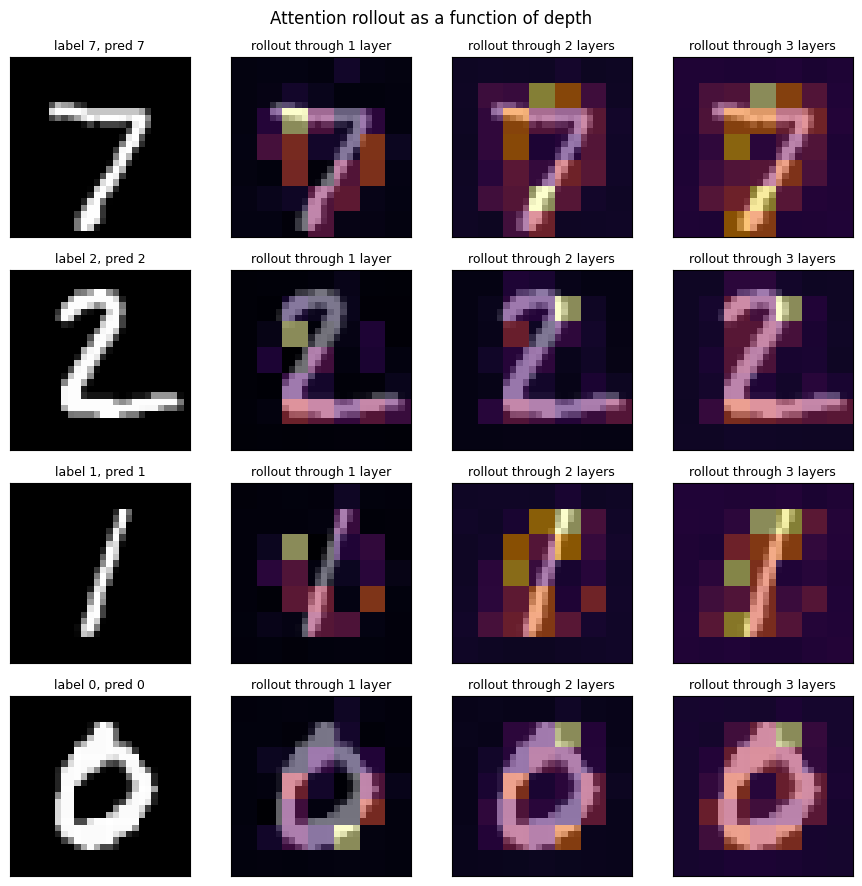

In [39]:
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for row, i in enumerate([0, 1, 2, 3]):
    axes[row, 0].imshow(probe_x[i, 0], cmap='gray'); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_title(f'label {probe_y[i].item()}, pred {pred_np[i]}', fontsize=9)
    for L in [1, 2, 3]:
        show_map(axes[row, L], probe_x[i, 0].numpy(), cls_map(attention_rollout(attn_np[i], upto=L)[0]), f'rollout through {L} layer{"s" if L > 1 else ""}')
plt.suptitle('Attention rollout as a function of depth'); plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

### Widget 7: rollout depth

Pick a test image and the number of layers to roll through. The bar chart on the right is the mass the class token puts on itself versus on the patches after the rollout: with more layers, more of the information the classifier uses has flowed in from the image.

In [40]:
def rollout_explorer(image=0, layers=3):
    R = attention_rollout(attn_np[image], upto=layers)[0]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    axes[0].imshow(probe_x[image, 0], cmap='gray'); axes[0].axis('off')
    axes[0].set_title(f'label {probe_y[image].item()}, predicted {pred_np[image]}')
    show_map(axes[1], probe_x[image, 0].numpy(), cls_map(R), f'rollout through {layers} layer(s)')
    axes[2].bar(['cls token itself', 'the 49 patches'], [R[0], R[1:].sum()], color=['#999999', '#C44E52'])
    axes[2].set_ylim(0, 1); axes[2].set_title('where the class token\'s mass sits')
    plt.tight_layout(); plt.show()

interact(rollout_explorer,
         image=IntSlider(min=0, max=11, value=0, description='test image', continuous_update=False),
         layers=IntSlider(min=1, max=3, value=3, description='layers'));

interactive(children=(IntSlider(value=0, continuous_update=False, description='test image', max=11), IntSlider…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| Pixels as tokens | $(3 \times 224 \times 224)^2 \approx 2.3 \times 10^{10}$ attention entries (90 GB per head per layer in float32); impossible. These are activations, not weights. |
| Patches as tokens | $16 \times 16$ patches give $196$ tokens and a $38{,}416$-entry attention matrix (about 150 KB). The tokenizer sets the cost of everything downstream. |
| Patch projection | Flatten each patch and apply one linear map: identical to `Conv2d(kernel = stride = P)`, so ViT is not convolution-free; the MLPs are stacks of $1 \times 1$ convolutions too. |
| ViT | $z_0 = [x_{\text{cls}}; x_p E] + E_{\text{pos}}$, pre-norm encoder blocks, classify from the class token. Parameters barely depend on $P$; compute has a $2T^2D$ term that does. |
| Inductive bias and data | With matched parameters and recipe, our CNN beat the ViT at every training-set size and the gap shrank as data grew: the miniature version of "ViT loses on ImageNet-1k, wins on JFT-300M". |
| What ViT learns | Class-token attention maps follow the strokes; attention rollout traces the flow through the residual stack; learned position embeddings recover the 2D layout (neighbours are far more similar than non-neighbours). |
| Improving ViT | Weight decay, stochastic depth, MLP dropout, MixUp and RandAugment stand in for data; DeiT adds a distillation token trained against a CNN teacher (the slide's soft KL loss, or the paper's hard argmax label). |
| Isotropic vs hierarchical | A ViT keeps one resolution and width throughout; CNNs and Swin shrink resolution and grow channels stage by stage, which dense tasks need. |
| Window attention | $4hwC^2 + 2M^2hwC$ instead of $4hwC^2 + 2(hw)^2C$: linear in the image size; equal to block-masked global attention. |
| Shifted windows | Cyclic shift plus a mask reproduces attention in the displaced windows exactly and keeps everything batched; alternating W-MSA and SW-MSA lets information cross window borders. |
| Relative position bias | $A = \text{Softmax}(QK^T/\sqrt{d} + B)V$ with $B$ indexed from a $(2M-1)^2 \times h$ table; no absolute position embedding. |
| Patch merging | Concatenate $2 \times 2$ tokens, LN, Linear $4C \to 2C$; the linear part is a stride-2 $2 \times 2$ convolution. |

### The three families at a glance

| | CNN (ResNet) | ViT | Swin |
|---|---|---|---|
| tokenizer | none (pixels) | $16 \times 16$ patches, linear projection | $4 \times 4$ patches, linear embedding |
| mixing across positions | $3 \times 3$ convolutions (local) | global self-attention | attention in $M \times M$ windows, shifted every other block |
| position information | implicit in the convolution | learned absolute embedding | learned relative bias inside each window |
| resolution over depth | shrinks, channels grow (hierarchical) | constant (isotropic) | shrinks by patch merging, channels double (hierarchical) |
| cost per layer in tokens $N$ | linear | quadratic | linear |
| inductive bias | locality, translation equivariance | almost none | locality inside windows, hierarchy |
| data appetite | modest | large (or heavy augmentation, or distillation) | between the two |

## Exercises

1. **Patch size on MNIST.** Retrain `TinyViT` with `P=7` (16 tokens) and `P=2` (196 tokens) on the 8000-image subset with the same recipe and report test accuracy and seconds per run against the $P = 4$ result above. Use `vit_macs` to predict the cost ratio first, then check it against the measured time. *In our runs $P = 7$ reached about 89 to 90% (versus 88% for $P = 4$); `vit_macs` predicts a 3.2x cheaper forward pass, but the measured time fell only slightly, because at this size the run is dominated by per-step overhead rather than arithmetic; the MAC ratio shows up in wall time only on larger models or on a GPU with larger batches.*

2. **Mean pooling instead of a class token.** Change `TinyViT.forward` to classify from the mean of the patch tokens (`t[:, 1:].mean(1)`) instead of `t[:, 0]`, retrain on 2000 and 8000 images, and compare with the class-token numbers in section 5. Which readout trains faster in this small regime, and what does that do to the attention-map visualizations of section 6?

3. **Regularization from the slide.** Add `nn.Dropout(0.1)` after each linear layer of the MLP in `Block` and, separately, weight decay 0.1 in `train_model`, and retrain on the 2000-image subset for 500 and then 1500 steps. Report the four test accuracies. *In our runs MLP dropout at 500 steps cost about one point at both 8000 and 2000 images; regularization slows fitting first and needs the longer 1500-step schedule to have a chance of paying back.*

4. **DeiT with augmentation.** Add a random shift of up to 2 pixels (`torch.roll` on the batch, or padding and a random crop) inside `train_model`, then retrain both the plain ViT and `DistilledViT` on the 2000-image subset for 1000 steps. Does the teacher help more once every batch is a fresh view that it has an opinion about? Report the gap between the two.

5. **Measure the receptive field of shifted windows.** Build a `TinySwin` with $M = 4$ on a $16 \times 16$ token grid and, using autograd (the gradient of one output token with respect to the input grid), count how many input tokens influence the centre token after one block, after two blocks (W-MSA then SW-MSA) and after four. Then set every `shift` to 0 and repeat: without the shift the receptive field must stay inside one $4 \times 4$ window no matter how many blocks you stack.